<a name="projet-7"></a>
# PROJET 7 : Loan Default Prediction #

## Contenu Partie N°2 ##
- Import des données
- A) Suppression des lignes et colonnes inutiles
  - Suppression des lignes de totalisation
  - Vérification des lignes en doublon
  - Vérification des colonnes entièrement à Null
  - Suppression des colonnes susceptible d'introduire du dataleakage ("Hardship", "Settlement", historique du remboursement...)
    - Suppression des colonnes "Hardship" (Plans de difficultés financières)
    - Suppression des colonnes "Settlement" (Règlements de dettes)
    - Suppression des colonnes liée à l'historique de remboursement du prêt et son état actuel
  - Suppression de la colonne "issue_d"
  - Suppression des lignes des "prêts conjoints"
  - Suppression des colonnes ne contenant aucune donnée
  - Suppression de l'Id
  - Suppression de(s) colonne(s) ayant une valeur unique
  - Suppression de(s) colonne(s) extrêmement corrélées
- B) Création de la variable cible (Loan Condition)
- C) Transformation de variables
  - Transformation d'une variable catégorielle en une variable numérique (emp_length)
  - Simplification d'une donnée ("addr_state" devient "region")
  - Création d'un ratio "Loan-to-Income" (Montant du prêt / Revenu annuel).
- D) Analyse Exploratoire des Données (E.D.A.)
- E) Data Cleaning
  - Traitement des valeurs nulles
    - Imputation par une valeur extrême élevée
    - Imputation par zéro
    - Imputation par la médiane
    - Imputation par 100
    - Imputation par le Mode (La valeur la plus fréquente)
  - Traitement des Outliers
- F) Analyse des corrélations

In [1]:
import gc
# import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import plotly.express as px
# import scipy.stats as sps
import seaborn as sns

<a name="import-des-donnees"></a>
## Import des données ##


In [2]:
df = pd.read_parquet("DATA/accepted_2007_to_2018Q4_filtered.parquet")


In [3]:
# # Création d'un échantillon

# # Sélection et concaténation des 5 premières, 5 dernières lignes et 200000 lignes tirées aléatoirement
# df_echantillon = pd.concat([df.head(5), df.sample(n=200000, random_state=42), df.tail(5)])

# # Sauvegarde de cet échantillon dans un nouveau fichier CSV
# # L'argument index=False évite de sauvegarder les anciens numéros de ligne comme une nouvelle colonne
# df_echantillon.to_csv("DATA/accepted_2007_to_2018Q4_sample_200k.csv", index=False)

# # Vérification des dimensions
# print(f"L'échantillon a été créé avec succès !")
# print(f"Dimensions du nouvel échantillon : {df_echantillon.shape}")

# df = df_echantillon

<a name="exploration-et-data-cleaning"></a>
## A) Suppression des lignes et colonnes inutiles ##


In [4]:
# Aperçu des 5 premières lignes

df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Aperçu des 5 dernières lignes

df.tail()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2260700,Total amount funded in policy code 2: 521953170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<a name="Retrait des lignes de totalisation"></a>
### Suppression des lignes de totalisation ###


In [6]:
# On cherche les lignes dont l'id contient "Total" (insensible à la casse)
lignes_total = df[df['id'].str.contains("Total", case=False, na=False)]

print(f"Nombre de lignes de totaux explicites détectées : {len(lignes_total)}")
print("\nContenu de la colonne 'id' pour ces lignes :")
print(lignes_total['id'].unique())

Nombre de lignes de totaux explicites détectées : 32

Contenu de la colonne 'id' pour ces lignes :
<ArrowStringArray>
['Total amount funded in policy code 1: 6417608175',
 'Total amount funded in policy code 2: 1944088810',
 'Total amount funded in policy code 1: 1741781700',
  'Total amount funded in policy code 2: 564202131',
 'Total amount funded in policy code 1: 1791201400',
  'Total amount funded in policy code 2: 651669342',
 'Total amount funded in policy code 1: 1443412975',
  'Total amount funded in policy code 2: 511988838',
 'Total amount funded in policy code 1: 2063142975',
  'Total amount funded in policy code 2: 823319310',
 'Total amount funded in policy code 1: 1538432075',
  'Total amount funded in policy code 2: 608903141',
 'Total amount funded in policy code 1: 2087217200',
  'Total amount funded in policy code 2: 662815446',
 'Total amount funded in policy code 1: 3503840175',
  'Total amount funded in policy code 2: 873652739',
 'Total amount funded in policy co

In [7]:
# On ne garde que les lignes qui ne contiennent PAS "Total" dans l'id
df = df[~df['id'].str.contains("Total", case=False, na=False)]

print(f"Lignes de totaux purgées. Nouvelle taille : {len(df)}")

Lignes de totaux purgées. Nouvelle taille : 1571637


In [8]:
# Compte des lignes où loan_amnt est manquant
nb_null_loan = df['loan_amnt'].isnull().sum()

print(f"Nombre de lignes parasites (loan_amnt nul) : {nb_null_loan}")

# Visualiser ces lignes pour confirmer qu'il s'agit bien de totaux
print("\nAperçu des colonnes 'id' de ces lignes :")
print(df[df['loan_amnt'].isnull()]['id'].unique())

Nombre de lignes parasites (loan_amnt nul) : 1

Aperçu des colonnes 'id' de ces lignes :
<ArrowStringArray>
['Loans that do not meet the credit policy']
Length: 1, dtype: str


In [9]:
# Suppression des lignes où loan_amnt est NaN
df = df.dropna(subset=['loan_amnt'])

# Vérification de la nouvelle taille du dataset
print(f"Nettoyage terminé. Nouvelles dimensions : {df.shape}")

# Vérification visuelle de la fin du fichier
df.tail()

Nettoyage terminé. Nouvelles dimensions : (1571636, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260694,89885898,NaN,24000.0,24000.0,24000.0,60 months,12.79,543.50,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260695,88977788,NaN,24000.0,24000.0,24000.0,60 months,10.49,515.74,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


<a name="Vérification des lignes en doublon"></a>
### Vérification des lignes en doublon ###


In [10]:
# Compter le nombre total de lignes 100% identiques
nb_doublons = df.duplicated().sum()

print(f"Nombre de lignes en doublon détectées : {nb_doublons}")

# Aperçu de ces doublons :
if nb_doublons > 0:
    print("\nAperçu des lignes dupliquées :")
    display(df[df.duplicated()].head())

Nombre de lignes en doublon détectées : 0


<a name="Vérification des colonnes entièrement à Null"></a>
### Vérification des colonnes entièrement à Null ###


In [11]:
# Liste des colonnes 100% nulles

all_null_cols = df.columns[df.isnull().all()].tolist()

if len(all_null_cols) > 0:
    print(f"Il y a {len(all_null_cols)} colonnes entièrement vides :")
    print(all_null_cols)
else:
    print("Aucune colonne n'est entièrement vide.")

Il y a 1 colonnes entièrement vides :
['member_id']


In [12]:
# Suppression de la colonne member_id

df = df.drop(columns=['member_id'])
print("La colonne 'member_id' a été supprimée.")

La colonne 'member_id' a été supprimée.


<a name="Suppression des colonnes Hardship, Settlement et historique"></a>
### Suppression des colonnes susceptible d'introduire du dataleakage ("Hardship", "Settlement", historique du remboursement...) ###


In [13]:
# Calcul du nombre de valeurs nulles par colonne
null_counts = df.isnull().sum()

# Affichage des 20 colonnes avec le plus de valeurs manquantes
print("Synthèse des valeurs manquantes (Top 20) :")
print(null_counts.sort_values(ascending=False).head(20))

Synthèse des valeurs manquantes (Top 20) :
orig_projected_additional_accrued_interest    1564044
sec_app_mths_since_last_major_derog           1563533
hardship_last_payment_amount                  1561808
payment_plan_start_date                       1561808
hardship_reason                               1561808
hardship_type                                 1561808
hardship_payoff_balance_amount                1561808
hardship_status                               1561808
hardship_start_date                           1561808
hardship_amount                               1561808
hardship_dpd                                  1561808
hardship_loan_status                          1561808
hardship_length                               1561808
hardship_end_date                             1561808
deferral_term                                 1561808
sec_app_revol_util                            1549939
revol_bal_joint                               1549545
sec_app_chargeoff_within_12_mths       

#### **Suppression des colonnes "Hardship" (Plans de difficultés financières)** ####

Ces colonnes concernent les emprunteurs qui ont rencontré de graves problèmes financiers (perte d'emploi, maladie) et qui ont négocié un plan de sauvetage temporaire ("Hardship plan") avec Lending Club :

 *   hardship_reason : La cause de la difficulté (chômage, etc.).
 *   hardship_type : Le type de plan mis en place.
 *   hardship_status : Le statut du plan (actif, terminé, annulé).
 *   hardship_amount : Le montant de la mensualité pendant le plan.
 *   hardship_start_date / hardship_end_date : Dates de début et de fin du plan.
 *   hardship_length : La durée du plan en mois.
 *   hardship_dpd : Nombre de jours de retard de paiement (Days Past Due) au moment du plan.
 *   hardship_loan_status : Le statut du prêt pendant le plan.
 *   hardship_payoff_balance_amount : Le montant total restant à payer à l'issue du plan.
 *   hardship_last_payment_amount : Le dernier paiement effectué sous ce régime.
 *   payment_plan_start_date : Le jour où le plan a officiellement commencé.
 *   deferral_term : Le nombre de mois pendant lesquels le paiement a été repoussé.
 *   orig_projected_additional_accrued_interest : Les intérêts supplémentaires qui vont s'accumuler à cause de ce plan.

Ces informations n'existent que parce que l'emprunteur a déjà cessé de payer normalement. 
Or, le but du Machine Learning est de prédire le défaut au moment où le prêt est accordé, donc moment où toutes ces colonnes sont inexistantes.

In [14]:
# Liste exhaustive des colonnes "Hardship"
cols_hardship = [
    'orig_projected_additional_accrued_interest',
    'hardship_reason', 
    'hardship_payoff_balance_amount',
    'hardship_last_payment_amount', 
    'payment_plan_start_date',
    'hardship_type', 
    'hardship_status', 
    'hardship_start_date',
    'deferral_term', 
    'hardship_amount', 
    'hardship_dpd',
    'hardship_loan_status', 
    'hardship_length', 
    'hardship_end_date',
    'hardship_flag'  
]

# Suppression des colonnes (errors='ignore' évite un plantage si une colonne est déjà absente)
df = df.drop(columns=cols_hardship, errors='ignore')

print("Les colonnes 'Hardship' ont été supprimées avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

Les colonnes 'Hardship' ont été supprimées avec succès.
Nouvelles dimensions du dataset : (1571636, 135)


#### **Suppression des colonnes "Settlement" (Règlements de dettes)** ####

Ces colonnes s'activent lorsqu'un prêt a définitivement fait défaut ("Charged Off") et que le service de recouvrement négocie avec l'emprunteur pour récupérer au moins une partie de l'argent (par exemple, solder la dette pour 40% du montant restant) :

 *   settlement_status : Le statut de l'accord de règlement (ex: complet, rompu).
 *   settlement_date : La date à laquelle le recouvrement a accepté le règlement.
 *   settlement_amount : Le montant final convenu pour clore la dette.
 *   settlement_percentage : Le pourcentage de la dette initiale que représente le règlement.
 *   settlement_term : Le nombre de mois accordés pour payer ce règlement.
 *   debt_settlement_flag_date : La date à laquelle le dossier a été marqué comme "en cours de règlement".


Comme pour le groupe "Hardship", un modèle qui voit un montant dans settlement_amount saura à 100% que le prêt est mauvais, rendant la prédiction inutile et biaisée.

In [15]:
# Liste exhaustive des colonnes "Settlement"
cols_settlement = [
    'settlement_status',
    'debt_settlement_flag_date',
    'settlement_term',
    'settlement_percentage',
    'settlement_date',
    'settlement_amount',
    'debt_settlement_flag'  
]

# Suppression des colonnes (errors='ignore' évite un plantage si une colonne est déjà absente)
df = df.drop(columns=cols_settlement, errors='ignore')

print("Les colonnes 'Settlement' ont été supprimées avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

Les colonnes 'Settlement' ont été supprimées avec succès.
Nouvelles dimensions du dataset : (1571636, 128)


#### **Suppression des colonnes liée à l'historique de remboursement du prêt et son état actuel** ####

 Ces variables décrivent l'historique de remboursement du prêt et son état actuel :

 *   out_prncp / out_prncp_inv : Capital restant dû (principal) sur le montant total financé / sur la part financée par les investisseurs.
 *   total_pymnt / total_pymnt_inv : Total des paiements reçus à ce jour pour le montant total financé / pour la part des investisseurs.
 *   total_rec_prncp : Capital (principal) remboursé par l'emprunteur à ce jour.
 *   total_rec_int : Intérêts remboursés par l'emprunteur à ce jour.
 *   total_rec_late_fee : Frais ou pénalités de retard perçus à ce jour.
 *   recoveries : Montants récupérés après que le prêt a été déclaré en perte (procédure de recouvrement post "charge-off").
 *   collection_recovery_fee : Frais de gestion facturés par les agences de recouvrement pour récupérer les fonds.
 *   last_pymnt_amnt : Montant du tout dernier paiement total reçu.
 *   last_pymnt_d : Date (mois) à laquelle le dernier paiement a été enregistré.
 *   last_credit_pull_d : Date la plus récente à laquelle le prêteur a consulté le dossier de crédit de l'emprunteur.
 *   next_pymnt_d : Date du prochain paiement.

Dans un projet de prédiction de défaut de paiement, l'objectif est de déterminer si un emprunteur va faire défaut au moment où il demande son prêt. Or, ces informations (paiements reçus, reliquat du capital, frais de retard) ne sont connues qu'après que le prêt a été accordé.

In [16]:
# Liste des colonnes de "Data Leakage" (données futures ou liées au comportement de remboursement)
cols_leakage = [
    'out_prncp', 
    'out_prncp_inv', 
    'total_pymnt', 
    'total_pymnt_inv',
    'total_rec_prncp', 
    'total_rec_int', 
    'total_rec_late_fee',
    'recoveries', 
    'collection_recovery_fee', 
    'last_pymnt_amnt',
    'last_pymnt_d', 
    'last_credit_pull_d',
    'next_pymnt_d',
    'last_fico_range_high',  
    'last_fico_range_low',  
    'pymnt_plan'
]

# Suppression des colonnes 
df = df.drop(columns=cols_leakage, errors='ignore')

print("Les colonnes de 'Data Leakage' ont été supprimées avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

Les colonnes de 'Data Leakage' ont été supprimées avec succès.
Nouvelles dimensions du dataset : (1571636, 112)


### **Suppression de la colonne "issue_d"** ###

Ce n'est techniquement pas du Data Leakage.
L'objectif est de prédire si un emprunteur va faire défaut avant de lui accorder le prêt.
Or, au moment où le client fait sa demande, la date du jour (qui deviendra le mois et l'année de issue_d) est connue.

Mais si l'on donne l'année "2014" ou "2015" à un algorithme, il risque d'apprendre des règles du type : "les prêts de 2014 ont eu beaucoup de défauts, donc l'année 2014 est un risque".

Le problème ? Quand vous déploierez ce modèle en production en 2025 ou 2026, l'algorithme ne saura pas comment interpréter ces nouvelles années qu'il n'a jamais vues pendant son entraînement. Il va donc perdre en performance.

Conserver issue_d dans les features risque d'apporter plus de problèmes (overfitting temporel) que de solutions. 


In [17]:
# Suppression des colonnes
cols_leakage = ['issue_d']
df = df.drop(columns=cols_leakage, errors='ignore')

print("Les colonnes de 'Data Leakage' ont été supprimées avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

Les colonnes de 'Data Leakage' ont été supprimées avec succès.
Nouvelles dimensions du dataset : (1571636, 111)


<a name="Suppression des lignes des prêts conjoints"></a>
### Suppression des lignes des "prêts conjoints" ###


In [18]:
# Calcul du nombre de valeurs nulles par colonne
null_counts = df.isnull().sum()

# Affichage des 20 colonnes avec le plus de valeurs manquantes
print("Synthèse des valeurs manquantes (Top 20) :")
print(null_counts.sort_values(ascending=False).head(20))

Synthèse des valeurs manquantes (Top 20) :
sec_app_mths_since_last_major_derog    1563533
sec_app_revol_util                     1549939
revol_bal_joint                        1549545
sec_app_open_acc                       1549544
sec_app_earliest_cr_line               1549544
sec_app_mort_acc                       1549544
sec_app_fico_range_low                 1549544
sec_app_num_rev_accts                  1549544
sec_app_open_act_il                    1549544
sec_app_chargeoff_within_12_mths       1549544
sec_app_inq_last_6mths                 1549544
sec_app_collections_12_mths_ex_med     1549544
sec_app_fico_range_high                1549544
verification_status_joint              1538919
dti_joint                              1538667
annual_inc_joint                       1538663
desc                                   1445571
mths_since_last_record                 1306305
mths_since_recent_bc_dlq               1195758
mths_since_last_major_derog            1156664
dtype: int64


**Suppression des lignes avec un "Co-emprunteur" (sec_app_... et ..._joint)**

Des colonnes (comme annual_inc_joint ou sec_app_fico_range_low) correspondent aux informations d'un second demandeur lorsque le prêt est fait à deux (demande conjointe).

Or, les prêts conjoints (à deux emprunteurs) ont une dynamique de risque très différente des prêts individuels (les revenus et les dettes sont cumulés). Mélanger les deux dans un même modèle peut embrouiller l'algorithme. 

Dans la mesure où ces prêts conjoints ne représentent que quelques pourcents du dataset, il semble préférable de les retirer.

In [19]:
# Voir combien il y a de prêts de chaque type
print("Répartition des types de prêts avant filtrage :")
print(df['application_type'].value_counts())

# Ne conserver que les prêts individuels
df = df[df['application_type'] == 'Individual']

# Supprimer la colonne 'application_type' devenue inutile
df = df.drop(columns=['application_type'])

print(f"\nPrêts conjoints supprimés ! Nouvelles dimensions : {df.shape}")

Répartition des types de prêts avant filtrage :
application_type
Individual    1538663
Joint App       32973
Name: count, dtype: int64

Prêts conjoints supprimés ! Nouvelles dimensions : (1538663, 110)


### **Suppression des colonnes ne contenant aucune donnée** ###


In [20]:
# Liste des colonnes 100% nulles

all_null_cols = df.columns[df.isnull().all()].tolist()

if len(all_null_cols) > 0:
    print(f"Il y a {len(all_null_cols)} colonnes entièrement vides :")
    print(all_null_cols)
else:
    print("Aucune colonne n'est entièrement vide.")

Il y a 16 colonnes entièrement vides :
['annual_inc_joint', 'dti_joint', 'verification_status_joint', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog']


In [21]:
# On supprime les colonnes qui sont 100% vides
df = df.dropna(axis=1, how='all')
print(f"Purge terminée ! Nouvelles dimensions du dataset : {df.shape}")

Purge terminée ! Nouvelles dimensions du dataset : (1538663, 94)


In [22]:
# Calcul du nombre de valeurs nulles par colonne
null_counts = df.isnull().sum()

# Affichage des 20 colonnes avec le plus de valeurs manquantes
print("Synthèse des valeurs manquantes (Top 20) :")
print(null_counts.sort_values(ascending=False).head(20))

Synthèse des valeurs manquantes (Top 20) :
desc                              1412598
mths_since_last_record            1279174
mths_since_recent_bc_dlq          1170015
mths_since_last_major_derog       1131669
mths_since_recent_revol_delinq    1018383
il_util                            956575
mths_since_rcnt_il                 884245
all_util                           865828
inq_last_12m                       865782
total_cu_tl                        865782
open_acc_6m                        865782
open_rv_24m                        865781
open_rv_12m                        865781
total_bal_il                       865781
open_act_il                        865781
max_bal_bc                         865781
open_il_24m                        865781
open_il_12m                        865781
inq_fi                             865781
mths_since_last_delinq             769341
dtype: int64


**Colonnes contenant du texte libre ou des données non structurées**

 *   emp_title (Titre du poste) : Le nom du poste ou métier renseigné librement par l'emprunteur lors de sa demande. Étant un champ de texte libre, il contient d'innombrables fautes de frappe, abréviations et variantes pour un même métier. En l'éat, il y a trop de valeurs uniques. Sans un traitement lourd, cette variable va faire "planter" ou sur-apprendre les modèles.

 *   desc (Description du prêt) : Un paragraphe rédigé par l'emprunteur pour expliquer pourquoi il a besoin de ce prêt. C'est du texte pur. Bien qu'il puisse contenir du sens, l'extraire demanderait des techniques de traitement qui sortent du cadre d'une modélisation standard.

 *   title (Titre du prêt) : Un titre court donné par l'emprunteur à son prêt (ex: "Debt Consolidation", "Credit Card Payoff"). Il fait doublon avec la colonne "purpose". Cependant, purpose est une liste déroulante contrôlée (donc propre et standardisée), alors que title est un texte libre soumis aux mêmes problèmes que emp_title.

 *   url (Lien URL) : L'adresse web de la page de la demande de prêt sur le site de Lending Club. Un lien web ne contient absolument aucune information statistique ou mathématique exploitable pour évaluer la solvabilité d'un individu.

 *   zip_code (Code postal) : Les trois premiers chiffres du code postal de l'emprunteur (pour des raisons d'anonymat, LC masque les derniers chiffres, ex: "902xx"). Même tronqués, les codes postaux génèrent beaucoup trop de catégories différentes. C'est trop lourd pour l'encodage. De plus, l'information géographique pertinente est déjà capturée de manière beaucoup plus propre par la colonne addr_state (l'État américain).



In [23]:
# Liste des colonnes de texte libre et métadonnées non structurées
cols_unstructured = [
    'emp_title', 
    'desc', 
    'title', 
    'url', 
    'zip_code'
]

# Suppression des colonnes (errors='ignore' permet d'éviter un plantage si une colonne est déjà absente)
df = df.drop(columns=cols_unstructured, errors='ignore')

print("Les colonnes de texte libre et métadonnées ont été supprimées avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

Les colonnes de texte libre et métadonnées ont été supprimées avec succès.
Nouvelles dimensions du dataset : (1538663, 89)


### **Suppression de l'Id** ###

L'identifiant unique n'a aucun pouvoir de prédiction sur le comportement financier de l'emprunteur. Le conserver lors de l'entraînement obligerait le modèle de Machine Learning à chercher des corrélations mathématiques là où il n'y a que du bruit.

In [24]:
# Suppression de la colonne 'id'
df = df.drop('id', axis=1)


### **Suppression de(s) colonne(s) ayant une valeur unique** ###


In [25]:
# La colonne policy_code est un indicateur qui précise si le prêt est conforme aux critères d'acceptation publics de Lending Club.
# Valeur = 1 : Le prêt est "publiquement disponible". Cela correspond aux données de prêts acceptés que l'on trouve généralement dans les fichiers "Accepted".
# Valeur = 2 : Le prêt n'est pas publiquement disponible (souvent lié à des produits spécifiques ou des tests de nouveaux modèles de score de crédit par la plateforme).

df.groupby('policy_code').size() \
    .reset_index(name='count') \
    .sort_values(by='count', ascending=False)

,policy_code,count
0,1.0,1538663


Absence de variance : 100 % des lignes ont la valeur "1".
Comme la valeur est la même pour tout le monde, elle n'apporte aucune information pour différencier un bon d'un mauvais payeur.
Elle doit donc être supprimée pour ne pas alourdir inutilement le traitement.


In [26]:
# Liste des colonnes constantes ou inutiles identifiées
cols_constant = ['policy_code']

# Suppression des colonnes (errors='ignore' évite l'erreur si la cellule est relancée)
df = df.drop(columns=cols_constant, errors='ignore')

print("La colonne 'policy_code' (sans variance) a été supprimée avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

La colonne 'policy_code' (sans variance) a été supprimée avec succès.
Nouvelles dimensions du dataset : (1538663, 87)


### **Suppression de(s) colonne(s) extrêmement corrélées** ###


In [27]:
# Sélection et affichage des 10 premières lignes pour comparaison
cols_to_compare = ['loan_amnt', 'funded_amnt', 'funded_amnt_inv']

print("Aperçu des montants :")
print(df[cols_to_compare].head(10))

# Vérification statistique rapide
print("\nStatistiques descriptives :")
print(df[cols_to_compare].describe())


Aperçu des montants :
    loan_amnt  funded_amnt  funded_amnt_inv
0      3600.0       3600.0           3600.0
1     24700.0      24700.0          24700.0
3     35000.0      35000.0          35000.0
4     10400.0      10400.0          10400.0
5     11950.0      11950.0          11950.0
6     20000.0      20000.0          20000.0
7     20000.0      20000.0          20000.0
8     10000.0      10000.0          10000.0
9      8000.0       8000.0           8000.0
10    22400.0      22400.0          22400.0

Statistiques descriptives :
          loan_amnt   funded_amnt  funded_amnt_inv
count  1.538663e+06  1.538663e+06     1.538663e+06
mean   1.464389e+04  1.463616e+04     1.461117e+04
std    8.745605e+03  8.742418e+03     8.747975e+03
min    5.000000e+02  5.000000e+02     0.000000e+00
25%    8.000000e+03  8.000000e+03     8.000000e+03
50%    1.250000e+04  1.245000e+04     1.237500e+04
75%    2.000000e+04  2.000000e+04     2.000000e+04
max    4.000000e+04  4.000000e+04     4.000000e+04


loan_amnt (Montant demandé) : C'est le montant total que l'emprunteur a demandé initialement lors de sa demande de prêt. C'est la valeur de base avant toute intervention de la plateforme ou des investisseurs.

funded_amnt (Montant financé) : C'est le montant total qui a été engagé pour le prêt.

funded_amnt_inv (Montant financé par les investisseurs) : C'est la part du prêt qui a été effectivement financée par des investisseurs individuels (particuliers) sur la plateforme.

Ces trois variables sont extrêmement corrélées (Multicolinéarité). 

Seule loan_amnt est conservée car elle représente l'intention initiale de l'emprunteur.

In [28]:
# Liste des colonnes redondantes (fortement corrélées à loan_amnt)
cols_redundant = ['funded_amnt', 'funded_amnt_inv']

# Suppression des colonnes (errors='ignore' évite l'erreur si la cellule est relancée)
df = df.drop(columns=cols_redundant, errors='ignore')

print("Les colonnes 'funded_amnt' et 'funded_amnt_inv' (redondantes) ont été supprimées avec succès.")
print(f"Nouvelles dimensions du dataset : {df.shape}")

Les colonnes 'funded_amnt' et 'funded_amnt_inv' (redondantes) ont été supprimées avec succès.
Nouvelles dimensions du dataset : (1538663, 85)


<a name="variable-cible"></a>
## B) Création de la variable cible (Loan Condition) ##


In [29]:
# Création de la variable cible (Loan Condition)
bad_loan = [
    "Charged Off", 
    "Default", 
    "Does not meet the credit policy. Status:Charged Off", 
    "In Grace Period",
    "Late (16-30 days)", 
    "Late (31-120 days)"
]

df['loan_condition_int'] = df['loan_status'].apply(lambda status: 1 if status in bad_loan else 0).astype(int)
df['loan_condition'] = np.where(df['loan_condition_int'] == 0, 'Good Loan', 'Bad Loan')

# Vérification rapide
df.groupby(['loan_status', 'loan_condition', 'loan_condition_int']).size() \
    .reset_index(name='count') \
    .sort_values(by=['loan_condition', 'count'], ascending=[False, False])

,loan_status,loan_condition,loan_condition_int,count
5,Fully Paid,Good Loan,0,1057295
1,Current,Good Loan,0,185896
4,Does not meet the credit policy. Status:Fully ...,Good Loan,0,1988
0,Charged Off,Bad Loan,1,262215
8,Late (31-120 days),Bad Loan,1,19289
6,In Grace Period,Bad Loan,1,7342
7,Late (16-30 days),Bad Loan,1,3843
3,Does not meet the credit policy. Status:Charge...,Bad Loan,1,761
2,Default,Bad Loan,1,34


## C) Transformation de variables ##


### Transformation d'une variable catégorielle en une variable numérique (emp_length) ###


In [30]:
# Conversion de l'ancienneté professionnelle
emp_length_mapping = {
    '10+ years': 10,
    '9 years': 9,
    '8 years': 8,
    '7 years': 7,
    '6 years': 6,
    '5 years': 5,
    '4 years': 4,
    '3 years': 3,
    '2 years': 2,
    '1 year': 1,
    '< 1 year': 0.5,
    'n/a': 0
}

df['emp_length_int'] = df['emp_length'].map(emp_length_mapping)

# Vérification rapide
df.groupby(['emp_length', 'emp_length_int']).size() \
    .reset_index(name='count') \
    .sort_values(by=['emp_length_int', 'count'], ascending=[False, False])

,emp_length,emp_length_int,count
1,10+ years,10.0,514602
9,9 years,9.0,58778
8,8 years,8.0,69469
7,7 years,7.0,66925
6,6 years,6.0,71385
5,5 years,5.0,95882
4,4 years,4.0,92266
3,3 years,3.0,123034
2,2 years,2.0,139003
0,1 year,1.0,101234


In [31]:
# Suppression de la colonne originale emp_length
df.drop(columns=['emp_length'], inplace=True)

# Vérification de la présence des colonnes restantes
print(f"La colonne 'emp_length' a été supprimée.")
print(f"Colonnes actuelles : {df.columns.tolist()}")

La colonne 'emp_length' a été supprimée.
Colonnes actuelles : ['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'home_ownership', 'annual_inc', 'verification_status', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', '

### Simplification d'une donnée ("addr_state" devient "region") ###


In [32]:
# Cartographie des régions
state_to_region = {
    'CA': 'West', 'OR': 'West', 'UT': 'West', 'WA': 'West', 'CO': 'West',
    'NV': 'West', 'AK': 'West', 'MT': 'West', 'HI': 'West', 'WY': 'West', 'ID': 'West',
    'AZ': 'SouthWest', 'TX': 'SouthWest', 'NM': 'SouthWest', 'OK': 'SouthWest',
    'GA': 'SouthEast', 'NC': 'SouthEast', 'VA': 'SouthEast', 'FL': 'SouthEast', 'KY': 'SouthEast',
    'SC': 'SouthEast', 'LA': 'SouthEast', 'AL': 'SouthEast', 'WV': 'SouthEast', 'DC': 'SouthEast',
    'AR': 'SouthEast', 'DE': 'SouthEast', 'MS': 'SouthEast', 'TN': 'SouthEast',
    'IL': 'MidWest', 'MO': 'MidWest', 'MN': 'MidWest', 'OH': 'MidWest', 'WI': 'MidWest',
    'KS': 'MidWest', 'MI': 'MidWest', 'SD': 'MidWest', 'IA': 'MidWest', 'NE': 'MidWest',
    'IN': 'MidWest', 'ND': 'MidWest',
    'CT': 'NorthEast', 'NY': 'NorthEast', 'PA': 'NorthEast', 'NJ': 'NorthEast', 'RI': 'NorthEast',
    'MA': 'NorthEast', 'MD': 'NorthEast', 'VT': 'NorthEast', 'NH': 'NorthEast', 'ME': 'NorthEast'
}

df['region'] = df['addr_state'].map(state_to_region)

# Vérification rapide
df.groupby('region').size() \
    .reset_index(name='count') \
    .sort_values(by='count', ascending=False)

,region,count
2,SouthEast,373961
4,West,356452
1,NorthEast,352519
0,MidWest,271051
3,SouthWest,184680


In [33]:
# Préparation des données
data = {
    'region': ['SouthEast', 'West', 'NorthEast', 'MidWest', 'SouthWest'],
    'count': [16561, 15902, 15582, 12019, 8033]
}
df_regions = pd.DataFrame(data)

# Mapping des régions vers les codes d'États US (ISO-3166)
region_map = {
    'SouthEast': ['AL', 'AR', 'FL', 'GA', 'KY', 'LA', 'MS', 'NC', 'SC', 'TN', 'VA', 'WV'],
    'West': ['AK', 'AZ', 'CA', 'CO', 'HI', 'ID', 'MT', 'NV', 'NM', 'OR', 'UT', 'WA', 'WY'],
    'NorthEast': ['CT', 'DE', 'ME', 'MD', 'MA', 'NH', 'NJ', 'NY', 'PA', 'RI', 'VT'],
    'MidWest': ['IL', 'IN', 'IA', 'KS', 'MI', 'MN', 'MO', 'NE', 'ND', 'OH', 'SD', 'WI'],
    'SouthWest': ['OK', 'TX']
}

# Liste dépliée pour avoir une ligne par État
state_data = []
for region, states in region_map.items():
    val = df_regions[df_regions['region'] == region]['count'].values[0]
    for state in states:
        state_data.append({'state': state, 'region': region, 'count': val})

df_map = pd.DataFrame(state_data)

# Création de la carte Choroplèthe
fig = px.choropleth(df_map, 
                    locations='state', 
                    locationmode="USA-states", 
                    color='count',
                    scope="usa",
                    hover_name='region',
                    color_continuous_scale="Viridis",
                    title='Répartition Géographique des Prêts par Région',
                    labels={'count': 'Nombre de Prêts'})

fig.show()

In [34]:
# Nettoyage de la mémoire 
del df_regions, df_map
gc.collect()

20

In [35]:
# Calcul du taux de défaut par État (en s'assurant que loan_status ou loan_condition a été calculé)
# Si cette cellule est placée avant la création de loan_condition_int, utiliser loan_status
bad_loans = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "In Grace Period", "Late (16-30 days)", "Late (31-120 days)"]
df_temp = df.copy()
df_temp['is_bad'] = df_temp['loan_status'].isin(bad_loans).astype(int)

state_risk = df_temp.groupby('addr_state')['is_bad'].mean().reset_index()
state_risk['is_bad'] = state_risk['is_bad'] * 100 # Conversion en pourcentage
state_risk.columns = ['State', 'Default_Rate']

# Création de la carte
fig = px.choropleth(
    state_risk,
    locations='State',
    locationmode="USA-states",
    color='Default_Rate',
    scope="usa",
    title="Taux de défaut de paiement par État (%)",
    color_continuous_scale="Reds",
    labels={'Default_Rate': 'Taux de défaut (%)'}
)

fig.show()

In [36]:
# Nettoyage de la mémoire
del df_temp, state_risk
gc.collect()

724

In [37]:
# Suppression de la colonne addr_state devenue redondante
df.drop(columns=['addr_state'], inplace=True)

# Confirmation et affichage des colonnes restantes
print(f"La colonne 'addr_state' a été supprimée.")
print(f"Colonnes géographiques conservées : {[col for col in df.columns if 'region' in col]}")

La colonne 'addr_state' a été supprimée.
Colonnes géographiques conservées : ['region']


### Création d'un ratio "Loan-to-Income" (Montant du prêt / Revenu annuel). ###


In [38]:
# Création de cette variable dans le Notebook 3

# # Création du ratio Loan-to-Income (Montant du prêt / Revenu annuel)
# # Le .replace(0, np.nan) évite une division par zéro si un revenu annuel est manquant ou à 0
# df['loan_to_income'] = df['loan_amnt'] / df['annual_inc'].replace(0, np.nan)

# # Vérification statistique rapide
# print("Statistiques descriptives du ratio Loan-to-Income :")
# print(df['loan_to_income'].describe())

----

In [39]:
# Taille maximale de l'échantillon souhaitée
sample_size = 2000000

# On retient la taille maximale ou la totalité du dataset s'il est plus petit
n_samples = min(sample_size, len(df))

# Création de l'échantillon
df_sample = df.sample(n=n_samples, random_state=42)

print(f"Taille du dataset original : {len(df)}")
print(f"Taille de l'échantillon conservé pour l'EDA : {len(df_sample)}")

Taille du dataset original : 1538663
Taille de l'échantillon conservé pour l'EDA : 1538663


----

## D) Analyse Exploratoire des Données (E.D.A.)


In [40]:
data_for_tables = df_sample.copy() 

# --- TABLEAU 1 : Statistiques Descriptives ---
# Sélection des colonnes numériques clés
num_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti']
desc_stats = data_for_tables[num_cols].describe().transpose()

# Ajout de la médiane et formatage
desc_stats['median'] = data_for_tables[num_cols].median()
table_1 = desc_stats[['mean', 'median', 'std', 'min', 'max']]
table_1.columns = ['Moyenne', 'Médiane', 'Écart-type', 'Min', 'Max']

print("--- TABLEAU 1 : SYNTHÈSE NUMÉRIQUE ---")
print(table_1.round(2))
print("\n")


--- TABLEAU 1 : SYNTHÈSE NUMÉRIQUE ---
             Moyenne   Médiane  Écart-type      Min          Max
loan_amnt   14643.89  12500.00     8745.60   500.00     40000.00
int_rate       13.28     12.79        4.74     5.31        30.99
annual_inc  77311.15  65000.00    70730.23  1896.00  10999200.00
dti            18.17     17.69        8.40    -1.00        49.96




In [41]:
# --- TABLEAU 2 : Analyse de la Variable Cible ---
target_counts = data_for_tables['loan_status'].value_counts()
target_perc = data_for_tables['loan_status'].value_counts(normalize=True) * 100

table_2 = pd.DataFrame({
    'Nombre': target_counts,
    'Proportion (%)': target_perc
})

print("--- TABLEAU 2 : DISTRIBUTION DU STATUT DES PRÊTS ---")
print(table_2.round(2))
print("\n")


--- TABLEAU 2 : DISTRIBUTION DU STATUT DES PRÊTS ---
                                                     Nombre  Proportion (%)
loan_status                                                                
Fully Paid                                          1057295           68.72
Charged Off                                          262215           17.04
Current                                              185896           12.08
Late (31-120 days)                                    19289            1.25
In Grace Period                                        7342            0.48
Late (16-30 days)                                      3843            0.25
Does not meet the credit policy. Status:Fully Paid     1988            0.13
Does not meet the credit policy. Status:Charged...      761            0.05
Default                                                  34            0.00




In [42]:
# --- TABLEAU 3 : Risque par Grade ---
# Calcul du taux de défaut (Charged Off) par Grade
def calculate_default_rate(series):
    return (series == 'Charged Off').mean() * 100

risk_by_grade = data_for_tables.groupby('grade')['loan_status'].agg(
    Volume='count',
    Taux_de_defaut=calculate_default_rate
)

print("--- TABLEAU 3 : RISQUE PAR GRADE ---")
print(risk_by_grade.round(2))

--- TABLEAU 3 : RISQUE PAR GRADE ---
       Volume  Taux_de_defaut
grade                        
A      256489            5.41
B      448688           11.49
C      445443           18.75
D      232242           25.62
E      109244           32.25
F       36365           38.92
G       10192           43.06


In [43]:
# On réinitialise l'index pour nettoyer les doublons générés lors de la concaténation
df = df.reset_index(drop=True)

# 4. Analyse Montant vs Condition (Numérique vs Catégorique)
print("--- TABLEAU 4 : Montant vs Condition ---")
print(df.groupby('loan_condition')['loan_amnt'].describe()[['mean', '50%', '75%']])


--- TABLEAU 4 : Montant vs Condition ---
                        mean      50%      75%
loan_condition                                
Bad Loan        15598.801298  14400.0  20500.0
Good Loan       14418.824763  12000.0  20000.0


In [44]:
# 5. Analyse Taux vs Condition (Numérique vs Catégorique)
print("\n--- TABLEAU 5 : Taux d'intérêt vs Condition ---")
print(df.groupby('loan_condition')['int_rate'].mean())



--- TABLEAU 5 : Taux d'intérêt vs Condition ---
loan_condition
Bad Loan     15.657523
Good Loan    12.714075
Name: int_rate, dtype: float64


In [45]:
# 6. Analyse Motif vs Condition (Catégorique vs Catégorique)
print("\n--- TABLEAU 6 : Risque par motif (Top 5) ---")
crosstab = pd.crosstab(df['purpose'], df['loan_condition'], normalize='index') * 100
print(crosstab.sort_values(by='Bad Loan', ascending=False).head(5))


--- TABLEAU 6 : Risque par motif (Top 5) ---
loan_condition     Bad Loan  Good Loan
purpose                               
small_business    28.450528  71.549472
house             22.890217  77.109783
renewable_energy  22.648752  77.351248
moving            22.503768  77.496232
medical           20.824060  79.175940


C:\Users\Damien\AppData\Local\Temp\ipykernel_17372\2099443743.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




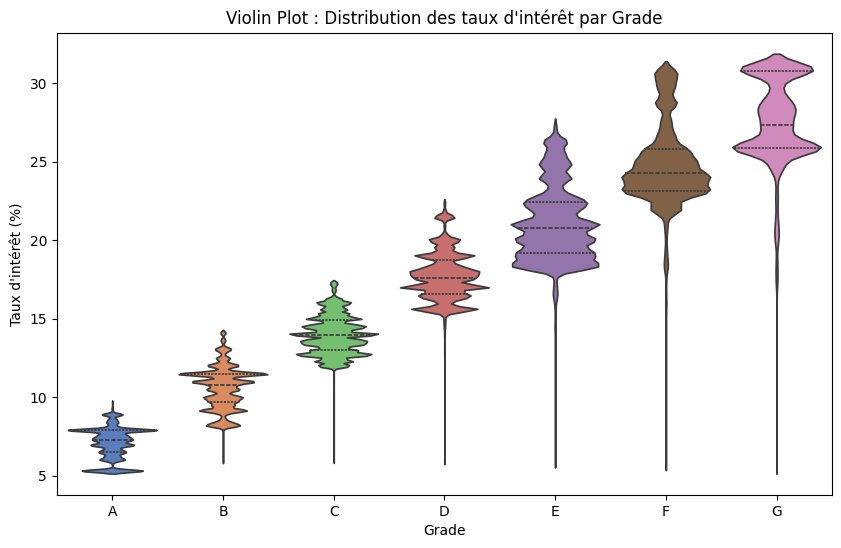

In [46]:
# 7. Distribution des taux d'intérêt par Grade (Violin Plot)

# Définir l'ordre exact souhaité pour l'axe X
ordre_grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

plt.figure(figsize=(10, 6))

# Ajout du paramètre "order"
sns.violinplot(
    x='grade', 
    y='int_rate', 
    data=df, 
    palette="muted", 
    inner="quartile",
    order=ordre_grades
)

plt.title("Violin Plot : Distribution des taux d'intérêt par Grade")
plt.xlabel("Grade")
plt.ylabel("Taux d'intérêt (%)")
plt.show()

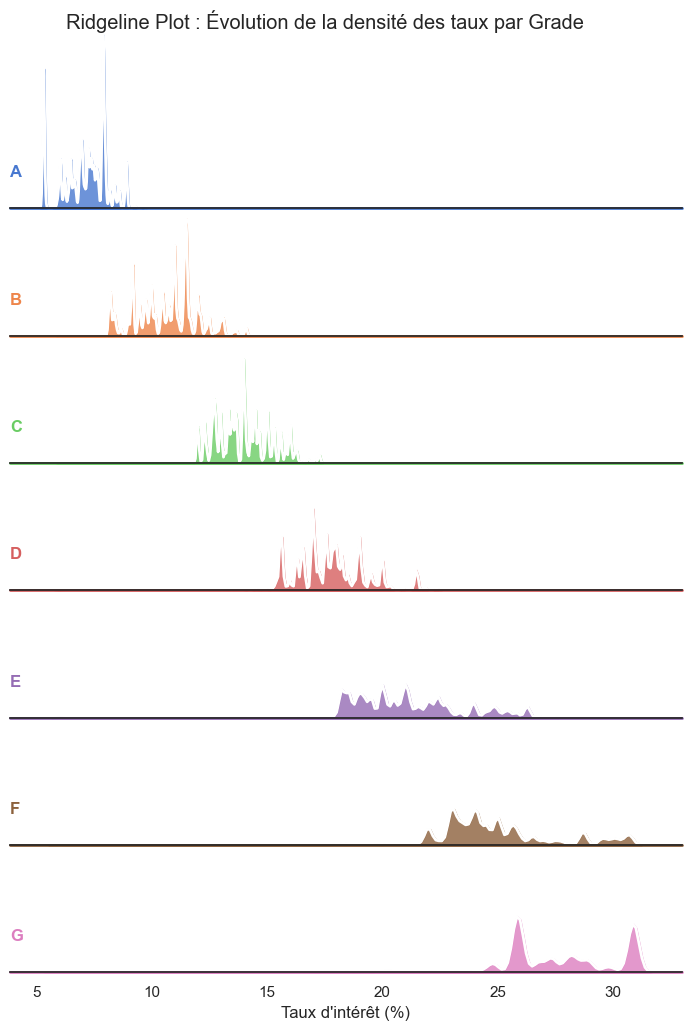

In [47]:
# 8. Évolution de la densité des taux par Grade (Ridgeline Plot)

# Configuration pour l'effet de chevauchement transparent
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# On définit l'ordre pour que la "montagne" descende de A à G
ordre_grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

# Création de la grille
g = sns.FacetGrid(df, row="grade", hue="grade", aspect=5, height=1.5, palette="muted", 
                  row_order=ordre_grades, hue_order=ordre_grades)

# Dessin des courbes
g.map(sns.kdeplot, "int_rate", bw_adjust=.5, clip_on=False, fill=True, alpha=0.8, linewidth=1.5)
g.map(sns.kdeplot, "int_rate", clip_on=False, color="w", lw=2, bw_adjust=.5)
g.map(plt.axhline, y=0, lw=2, clip_on=False)

def label_text(x, color, label):
    ax = plt.gca()
    # On positionne le texte tout à gauche (x=0) et un peu au-dessus de la ligne (y=0.2)
    ax.text(0, 0.2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

# On applique cette fonction à notre grille
g.map(label_text, "int_rate")

# Ajustement du chevauchement
g.fig.subplots_adjust(hspace=-0.3)

# Nettoyage des titres et de l'axe Y
g.set_titles("")
g.set(yticks=[], ylabel="")

# On retire uniquement l'axe de gauche
g.despine(left=True)

# Ajout du titre de l'axe X tout en bas
g.set_axis_labels("Taux d'intérêt (%)", "")

plt.suptitle("Ridgeline Plot : Évolution de la densité des taux par Grade", y=0.98)
plt.show()

# Restauration du thème classique pour la suite de votre notebook
sns.set_theme(style="whitegrid")

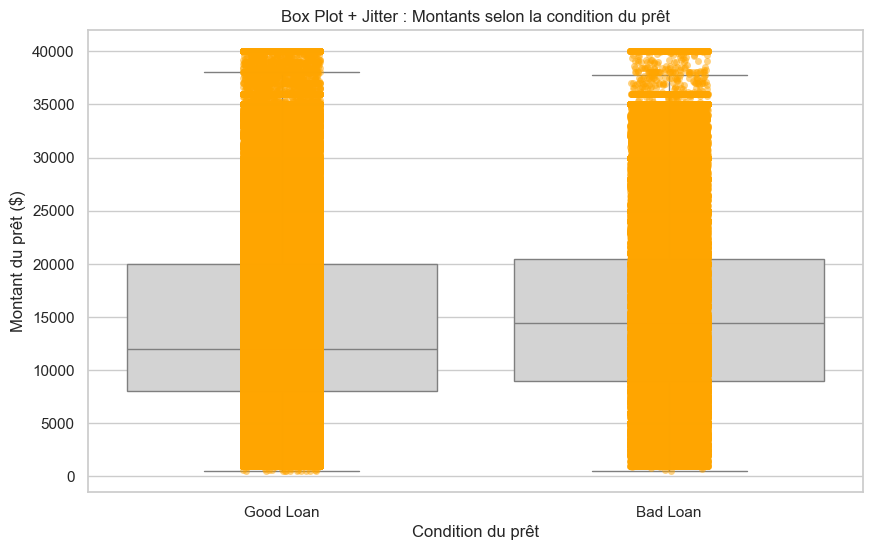

In [48]:
# 9. Montants selon la condition du prêt (Box Plot + Jitter)

plt.figure(figsize=(10, 6))
# On dessine la boîte grise en fond (sans les outliers pour plus de clarté)
sns.boxplot(x='loan_condition', y='loan_amnt', data=df, color="lightgray", showfliers=False)

# On ajoute les points individuels par dessus (le jitter éparpille les points horizontalement)
sns.stripplot(x='loan_condition', y='loan_amnt', data=df, color="orange", alpha=0.5, jitter=True)

plt.title("Box Plot + Jitter : Montants selon la condition du prêt")
plt.xlabel("Condition du prêt")
plt.ylabel("Montant du prêt ($)")
plt.show()

C:\Users\Damien\AppData\Local\Temp\ipykernel_17372\226462640.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




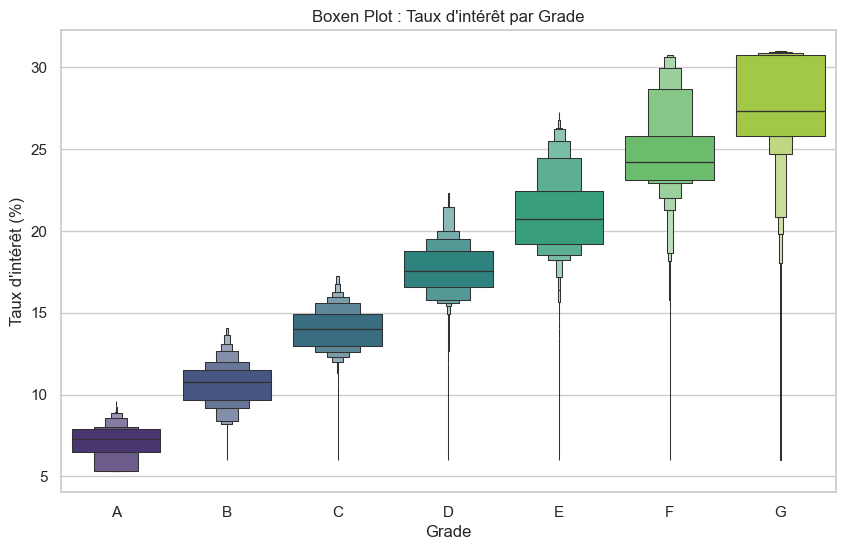

In [49]:
# 10. Taux d'intérêt par Grade (Boxen Plot)

# Définition de l'ordre logique des grades
ordre_grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

plt.figure(figsize=(10, 6))

# Ajout du paramètre order=ordre_grades
sns.boxenplot(
    x='grade', 
    y='int_rate', 
    data=df, 
    palette="viridis",
    order=ordre_grades
)

plt.title("Boxen Plot : Taux d'intérêt par Grade")
plt.xlabel("Grade")
plt.ylabel("Taux d'intérêt (%)")
plt.show()

C:\Users\Damien\AppData\Local\Temp\ipykernel_17372\640588722.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




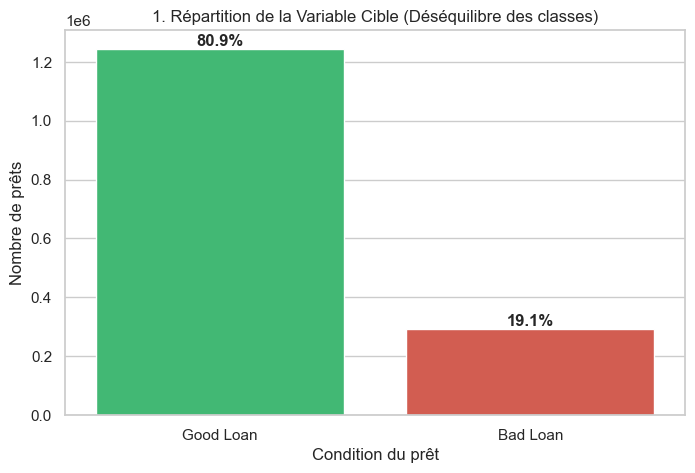

C:\Users\Damien\AppData\Local\Temp\ipykernel_17372\640588722.py:34: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




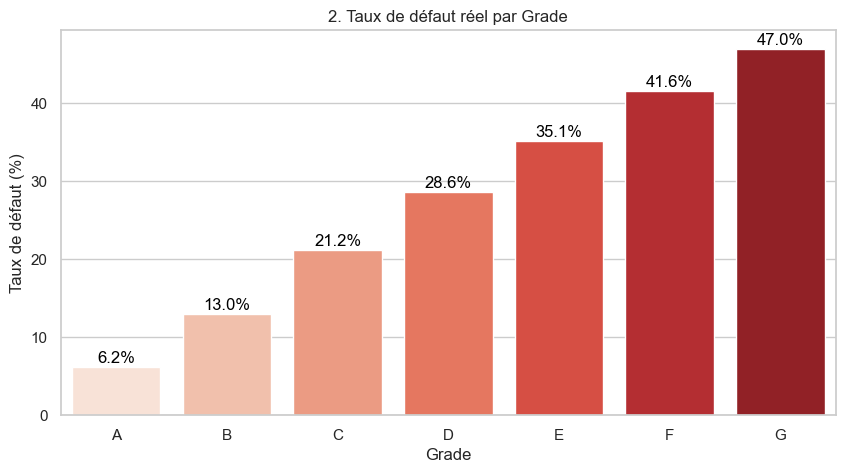

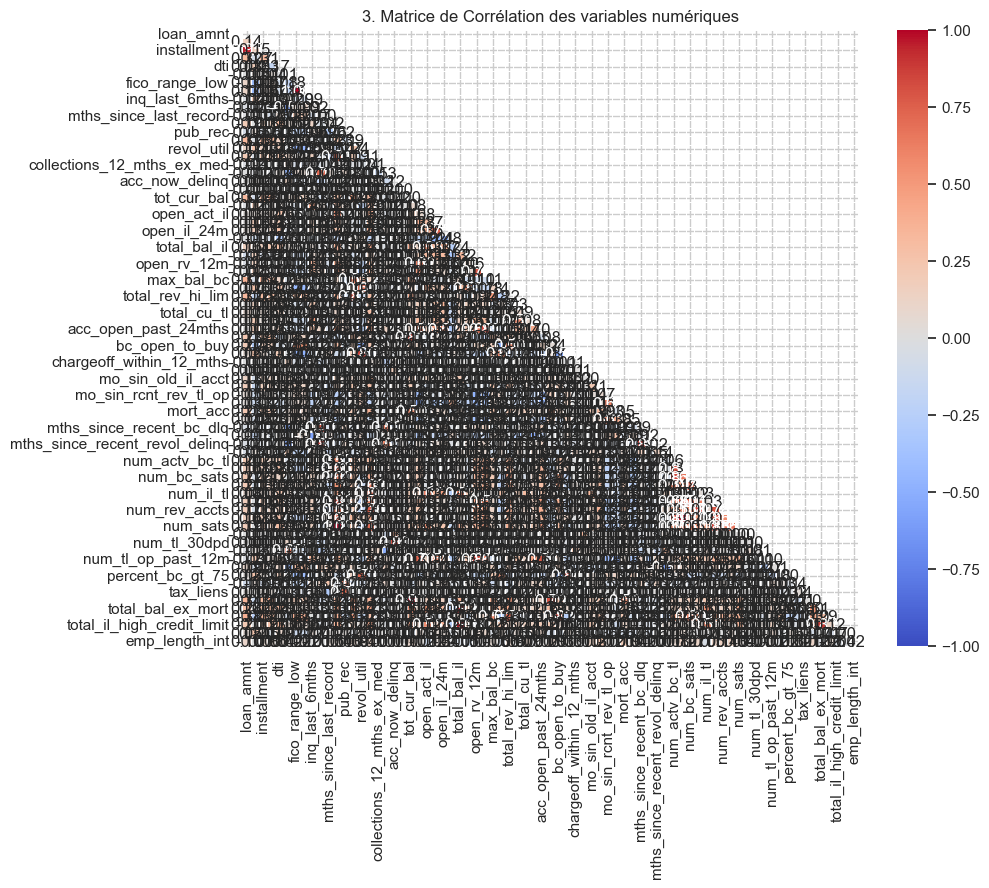

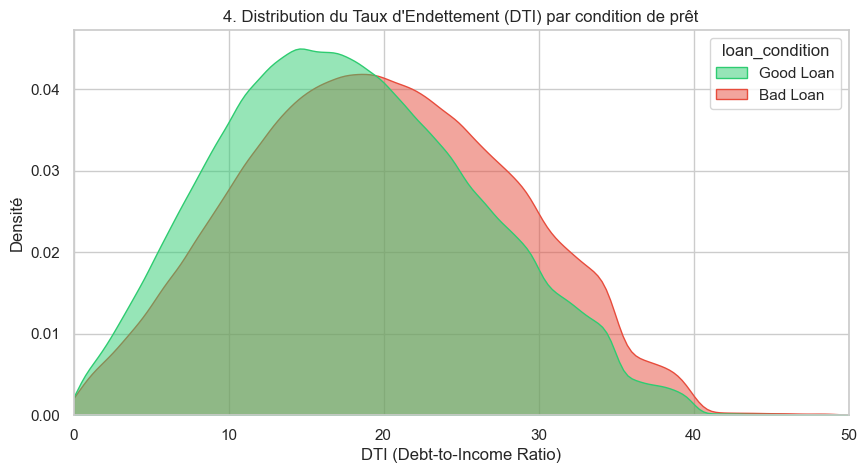

In [50]:
# Configuration générale pour l'esthétique
sns.set_theme(style="whitegrid")
ordre_grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
palette_cible = {'Good Loan': '#2ecc71', 'Bad Loan': '#e74c3c'} # Vert et Rouge

# ==========================================
# 1. Répartition de la Variable Cible
# ==========================================
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='loan_condition', palette=palette_cible, order=['Good Loan', 'Bad Loan'])

# Ajout des pourcentages sur les barres
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontweight='bold')

plt.title("1. Répartition de la Variable Cible (Déséquilibre des classes)")
plt.xlabel("Condition du prêt")
plt.ylabel("Nombre de prêts")
plt.show()


# ==========================================
# 2. Taux de défaut réel par Grade
# ==========================================
plt.figure(figsize=(10, 5))
# Calcul du pourcentage de défauts pour chaque Grade
taux_defaut = df[df['loan_condition'] == 'Bad Loan'].groupby('grade').size() / df.groupby('grade').size() * 100
taux_defaut = taux_defaut.reset_index(name='taux')

sns.barplot(data=taux_defaut, x='grade', y='taux', palette="Reds", order=ordre_grades)
plt.title("2. Taux de défaut réel par Grade")
plt.xlabel("Grade")
plt.ylabel("Taux de défaut (%)")

# Ajout de la valeur exacte au-dessus des barres
for index, row in taux_defaut.iterrows():
    plt.text(ordre_grades.index(row['grade']), row['taux'] + 0.5, f"{row['taux']:.1f}%", color='black', ha="center")
    
plt.show()


# ==========================================
# 3. Matrice de Corrélation
# ==========================================
plt.figure(figsize=(10, 8))
# Sélection uniquement des variables numériques (int, float)
df_num = df.select_dtypes(include=[np.number])

corr = df_num.corr()
# Création d'un masque pour cacher la moitié supérieure (redondante) du tableau
masque = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=masque, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("3. Matrice de Corrélation des variables numériques")
plt.show()


# ==========================================
# 4. Impact du DTI (Taux d'Endettement)
# ==========================================
plt.figure(figsize=(10, 5))
# Courbe de densité avec un remplissage (fill=True)
sns.kdeplot(data=df, x='dti', hue='loan_condition', common_norm=False, 
            fill=True, palette=palette_cible, alpha=0.5)

plt.title("4. Distribution du Taux d'Endettement (DTI) par condition de prêt")
plt.xlabel("DTI (Debt-to-Income Ratio)")
plt.ylabel("Densité")

# On limite généralement l'axe X à 50 ou 60 car le DTI a souvent des valeurs aberrantes très lointaines
plt.xlim(0, 50) 
plt.show()

In [51]:
# Purge des DataFrames statistiques intermédiaires et de l'échantillon
del data_for_tables, desc_stats, table_1, table_2, target_counts, target_perc, risk_by_grade
gc.collect()

164400

## E) Data Cleaning

### Traitement des valeurs nulles


In [52]:
drop_df = df_sample


In [53]:
def get_missing_value_stats(input_df):
    df_null = pd.DataFrame({
        'Missing Count': input_df.isnull().sum(),
        'Missing Percent': 100 * input_df.isnull().sum() / len(input_df),
        'Type': input_df.dtypes
    })
    missing_values = df_null[df_null['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False) #改
    return missing_values

def get_value_stats(input_df):
    df_null = pd.DataFrame({
        '#Count': input_df.notna().sum(),
        '%Populated': 100 * input_df.notna().sum() / len(input_df),
        '#Unique Values':input_df.nunique(),
        'Most Common Value': input_df.mode().iloc[0],
        'Type': input_df.dtypes
    })

    missing_values = df_null[df_null['#Count'] > 0].sort_values(by='#Count', ascending=False)

    return missing_values

missing_stats = get_missing_value_stats(drop_df)

colonnes_concernees = missing_stats[missing_stats['Missing Percent']>0]

with pd.option_context('display.max_rows', None):
    print(f"Nombre de colonnes concernées : {len(colonnes_concernees)}\n")
    display(colonnes_concernees)

Nombre de colonnes concernées : 68



,Missing Count,Missing Percent,Type
mths_since_last_record,1279174,83.135423,float64
mths_since_recent_bc_dlq,1170015,76.041017,float64
mths_since_last_major_derog,1131669,73.548854,float64
mths_since_recent_revol_delinq,1018383,66.186228,float64
il_util,956575,62.169234,float64
mths_since_rcnt_il,884245,57.468400,float64
all_util,865828,56.271451,float64
inq_last_12m,865782,56.268462,float64
total_cu_tl,865782,56.268462,float64
open_acc_6m,865782,56.268462,float64


#### Imputation par une valeur extrême élevée ####

La valeur est manquante parce que l'événement n'est jamais arrivé. 
Par exemple, une personne qui n'a jamais eu d'incident de paiement n'aura pas de valeur pour "mois écoulés depuis le dernier incident". C'est donc une bonne nouvelle vis-à-vis de son profil de risque.

L'imputation proposée consiste à remplacer les valeurs manquantes par un nombre artificiellement très élevé (999).

In [54]:
# Liste des colonnes cibles
cols_to_check = [
    'mths_since_last_record',          # Mois écoulés depuis le dernier enregistrement public (ex: faillite, jugement)
    'mths_since_recent_bc_dlq',        # Mois écoulés depuis la dernière délinquance sur un compte de carte bancaire
    'mths_since_last_major_derog',     # Mois écoulés depuis la dernière dérogation majeure (retard de 90+ jours)
    'mths_since_recent_revol_delinq',  # Mois écoulés depuis la dernière délinquance sur un crédit renouvelable
    'mths_since_last_delinq',          # Mois écoulés depuis la toute dernière délinquance (tout type de compte)
    'mths_since_rcnt_il',              # Mois écoulés depuis l'ouverture du prêt à tempérament le plus récent
    'mths_since_recent_inq',           # Mois écoulés depuis la demande de renseignement (inquiry) la plus récente
    'mo_sin_old_il_acct',              # Mois écoulés depuis l'ouverture du prêt à tempérament le plus ancien
    'mo_sin_rcnt_rev_tl_op',           # Mois écoulés depuis l'ouverture du compte renouvelable le plus récent
    'mo_sin_old_rev_tl_op',            # Mois écoulés depuis l'ouverture du compte renouvelable le plus ancien
    'mo_sin_rcnt_tl',                  # Mois écoulés depuis l'ouverture de la ligne de crédit la plus récente (tout type)
    'mths_since_recent_bc'             # Mois écoulés depuis l'ouverture du compte de carte bancaire le plus récent
]

# Calcul du min, max et du nombre de valeurs manquantes (NaN)
stats_recap = drop_df[cols_to_check].agg(['min', 'max', lambda x: x.isnull().sum()])
stats_recap.rename(index={'<lambda>': 'nb_missing'}, inplace=True)

# Affichage des résultats
print("Statistiques descriptives pour les colonnes de temps écoulé :")
display(stats_recap.transpose())

Statistiques descriptives pour les colonnes de temps écoulé :


,min,max,nb_missing
mths_since_last_record,0.0,129.0,1279174.0
mths_since_recent_bc_dlq,0.0,202.0,1170015.0
mths_since_last_major_derog,0.0,226.0,1131669.0
mths_since_recent_revol_delinq,0.0,202.0,1018383.0
mths_since_last_delinq,0.0,226.0,769341.0
mths_since_rcnt_il,0.0,511.0,884245.0
mths_since_recent_inq,0.0,25.0,201101.0
mo_sin_old_il_acct,0.0,999.0,113734.0
mo_sin_rcnt_rev_tl_op,0.0,438.0,70277.0
mo_sin_old_rev_tl_op,2.0,901.0,70277.0


In [55]:
# Colonnes à imputer par une valeur élevée (999)
cols_high_val = [
    'mths_since_last_record', 
    'mths_since_recent_bc_dlq', 
    'mths_since_last_major_derog', 
    'mths_since_recent_revol_delinq', 
    'mths_since_last_delinq', 
    'mths_since_rcnt_il',
    'mths_since_recent_inq', 
    'mo_sin_old_il_acct', 
    'mo_sin_rcnt_rev_tl_op', 
    'mo_sin_old_rev_tl_op', 
    'mo_sin_rcnt_tl', 
    'mths_since_recent_bc'
]

# Application de l'imputation
drop_df[cols_high_val] = drop_df[cols_high_val].fillna(999)

# Vérification : Doit afficher 0 pour toutes ces colonnes
print(drop_df[cols_high_val].isnull().sum())

mths_since_last_record            0
mths_since_recent_bc_dlq          0
mths_since_last_major_derog       0
mths_since_recent_revol_delinq    0
mths_since_last_delinq            0
mths_since_rcnt_il                0
mths_since_recent_inq             0
mo_sin_old_il_acct                0
mo_sin_rcnt_rev_tl_op             0
mo_sin_old_rev_tl_op              0
mo_sin_rcnt_tl                    0
mths_since_recent_bc              0
dtype: int64


#### Imputation par zéro ####

L'absence de donnée pour certains compteurs (nombre de comptes, d'incidents, etc.) signifie a priori : « aucun ».
Le « null » peut donc être remplacé par « zéro ».

In [56]:
# La liste des colonnes validées pour une imputation par 0
cols_to_zero = [
    'il_util',                    # Taux d'utilisation des prêts à tempérament
    'all_util',                   # Taux d'utilisation global (tous types de crédit confondus)
    'open_acc_6m',                # Nombre de comptes ouverts au cours des 6 derniers mois
    'total_cu_tl',                # Nombre de comptes auprès de coopératives de crédit (Credit Unions)
    'inq_last_12m',               # Nombre de demandes de renseignements de crédit ces 12 derniers mois
    'open_act_il',                # Nombre de prêts à tempérament actuellement actifs
    'open_il_12m',                # Nombre de prêts à tempérament ouverts ces 12 derniers mois
    'open_il_24m',                # Nombre de prêts à tempérament ouverts ces 24 derniers mois
    'total_bal_il',               # Solde total dû sur les prêts à tempérament
    'open_rv_24m',                # Nombre de crédits renouvelables ouverts ces 24 derniers mois
    'open_rv_12m',                # Nombre de crédits renouvelables ouverts ces 12 derniers mois
    'inq_fi',                     # Nombre de demandes de renseignements pour financement personnel
    'num_tl_120dpd_2m',           # Nombre de comptes en retard de 120 jours (sur les 2 derniers mois)
    'num_rev_accts',              # Nombre total de comptes de crédit renouvelable (ouverts ou fermés)
    'num_il_tl',                  # Nombre total de comptes de prêts à tempérament
    'total_rev_hi_lim',           # Limite de crédit totale autorisée sur les comptes renouvelables
    'num_tl_30dpd',               # Nombre de comptes actuellement en retard de 30 jours
    'num_actv_bc_tl',             # Nombre de comptes de cartes bancaires actuellement actifs
    'num_op_rev_tl',              # Nombre de comptes de crédit renouvelable actuellement ouverts
    'num_bc_tl',                  # Nombre total de comptes de cartes bancaires (ouverts ou fermés)
    'tot_coll_amt',               # Montant total des recouvrements dus par l'emprunteur
    'total_il_high_credit_limit', # Limite de crédit totale pour l'ensemble des prêts à tempérament
    'num_tl_90g_dpd_24m',         # Nombre de comptes avec un retard de 90+ jours ces 24 derniers mois
    'tot_hi_cred_lim',            # Limite de crédit globale totale (tous comptes)
    'num_rev_tl_bal_gt_0',        # Nombre de comptes de crédit renouvelable avec un solde supérieur à 0
    'num_tl_op_past_12m',         # Nombre de comptes (tout type) ouverts ces 12 derniers mois
    'num_actv_rev_tl',            # Nombre de comptes de crédit renouvelable actuellement actifs
    'num_accts_ever_120_pd',      # Nombre de comptes ayant déjà eu un retard de 120 jours ou plus
    'bc_util',                    # Taux d'utilisation global des cartes bancaires
    'percent_bc_gt_75',           # Pourcentage de cartes bancaires utilisées à plus de 75 % de leur limite
    'bc_open_to_buy',             # Montant total encore disponible pour des achats sur les cartes bancaires
    'num_bc_sats',                # Nombre de comptes de cartes bancaires "satisfaisants" (en règle)
    'num_sats',                   # Nombre total de comptes "satisfaisants" (en règle)
    'mort_acc',                   # Nombre de comptes de prêts hypothécaires (immobilier)
    'total_bc_limit',             # Limite de crédit totale autorisée sur les cartes bancaires
    'acc_open_past_24mths',       # Nombre total de comptes ouverts au cours des 24 derniers mois
    'total_bal_ex_mort',          # Solde total des crédits en cours à l'exclusion des prêts hypothécaires
    'pub_rec_bankruptcies',       # Nombre de faillites publiques déclarées
    'revol_util',                 # Taux d'utilisation du crédit renouvelable (en pourcentage)
    'collections_12_mths_ex_med', # Nombre de mises en recouvrement (hors frais médicaux) ces 12 derniers mois
    'chargeoff_within_12_mths',   # Nombre de radiations de créances (défaut acté) ces 12 derniers mois
    'tax_liens',                  # Nombre de privilèges fiscaux (dettes fiscales non réglées)
    'inq_last_6mths',             # Nombre de demandes de crédit au cours des 6 derniers mois
    'open_acc',                   # Nombre de lignes de crédit actuellement ouvertes
    'total_acc',                  # Nombre total de lignes de crédit de l'emprunteur (actives ou non)
    'acc_now_delinq',             # Nombre de comptes actuellement en défaut (délinquance)
    'delinq_2yrs',                # Nombre d'incidents de retard de +30 jours sur les 2 dernières années
    'delinq_amnt',                # Montant total des impayés (délinquance) actuels
    'pub_rec',                    # Nombre d'enregistrements publics défavorables
    'max_bal_bc',                 # Solde actuel maximum sur l'ensemble des cartes bancaires
    'avg_cur_bal',                # Solde actuel moyen de l'ensemble des comptes
    'tot_cur_bal',                # Solde actuel total de l'ensemble des comptes
    'emp_length_int'              # Ancienneté dans l'emploi actuel (en années)
    
]

# Application de l'imputation par 0 
drop_df[cols_to_zero] = drop_df[cols_to_zero].fillna(0)

# Vérification finale
print(f"Les {len(cols_to_zero)} colonnes ont bien été imputées par 0.")
print("Valeurs NaN restantes dans les colonnes traitées :", drop_df[cols_to_zero].isnull().sum().sum())

Les 53 colonnes ont bien été imputées par 0.
Valeurs NaN restantes dans les colonnes traitées : 0


#### Imputation par la médiane ####


In [57]:
# Liste des colonnes à imputer par la médiane
cols_to_median = [
    'annual_inc'      # Revenu annuel de l'emprunteur
    #'loan_to_income'  # Ratio entre le montant du prêt et le revenu
]

# Calcul des médianes pour chaque colonne
print("Valeurs médianes calculées :")
print(drop_df[cols_to_median].median())
print("-" * 30)

# Application de l'imputation par la médiane
drop_df[cols_to_median] = drop_df[cols_to_median].fillna(drop_df[cols_to_median].median())

# Vérification finale
print(f"Les {len(cols_to_median)} colonnes ont bien été imputées par la médiane.")
print("Valeurs NaN restantes dans ces colonnes :", drop_df[cols_to_median].isnull().sum().sum())

Valeurs médianes calculées :
annual_inc    65000.0
dtype: float64
------------------------------
Les 1 colonnes ont bien été imputées par la médiane.
Valeurs NaN restantes dans ces colonnes : 0


#### Imputation par 100 ####

Pour la colonne "pct_tl_nvr_dlq" (Pourcentage de comptes jamais en défaut), on peut supposer que le "null" signifie que l'emprunteur n'a jamais défaut ; l'imputation logique est donc : 100.

In [58]:
# Imputation par 100 pour le pourcentage de comptes sans défaut
drop_df['pct_tl_nvr_dlq'] = drop_df['pct_tl_nvr_dlq'].fillna(100)

#### Imputation par le Mode (La valeur la plus fréquente) ####

La colonne : "earliest_cr_line" ne contient que quelques "null". 
Statistiquement, ces lignes pourraient être supprimées sans perte d'information.

Pour les conserver malgré tout, il est proposé d'imputer les valeurs manquantes par le mois et l'année d'ouverture de crédit les plus fréquents dans la source de données.

In [59]:
# Trouver la date la plus fréquente (le mode)
mode_date = drop_df['earliest_cr_line'].mode()[0]

# Imputer les valeurs manquantes
drop_df['earliest_cr_line'] = drop_df['earliest_cr_line'].fillna(mode_date)

print(f"Valeurs manquantes remplacées par : {mode_date}")

Valeurs manquantes remplacées par : Aug-2001


**Correction des valeurs "nulles" éventuellement oubliées dans les traitements précédents** 

S'il se trouve encore des valeurs manquantes dans des colonnes de chiffres, il est mis un 0. 
S'il se trouve encore des valeurs manquantes dans des colonnes de texte, il met le caractère "0".

In [68]:
fillna_df = drop_df.copy()

In [69]:
fillna_df.isnull().sum().max()

np.int64(0)

In [70]:
# Identifier et remplir les colonnes numériques avec le chiffre 0
cols_num = fillna_df.select_dtypes(include=['number']).columns
fillna_df[cols_num] = fillna_df[cols_num].fillna(0)

# Identifier et remplir les colonnes de texte avec le texte "0" (ou "Inconnu", "Missing", etc.)
cols_str = fillna_df.select_dtypes(include=['object', 'str']).columns
fillna_df[cols_str] = fillna_df[cols_str].fillna("0")

# Vérifier le nombre maximum de valeurs nulles restantes
fillna_df.isnull().sum().max()

np.int64(0)

----

**Vérification du déséquilibre (Imbalanced Classes)** 


In [71]:
len(fillna_df['loan_condition_int'])
# Loan Ratios (Imbalanced classes)
fillna_df['loan_condition_int'].value_counts()/len(fillna_df['loan_condition_int']) * 100

loan_condition_int
0    80.926038
1    19.073962
Name: count, dtype: float64

----

### Traitement des Outliers

Elimination des valeurs extrêmes en utilisant le 99ème percentile plutôt que la méthode de l'écart interquartile qui éliminerait trop de lignes

In [73]:
# 1. Définir les colonnes à traiter
cols_to_filter = ['annual_inc', 'dti', 'open_acc', 'total_acc', 'revol_util', 'revol_bal']

print(f"Lignes au départ dans fillna_df : {len(fillna_df)}")

# 2. Créer un masque initialisé à True
mask = pd.Series(True, index=fillna_df.index)

# 3. Application dynamique et diagnostic
for col in cols_to_filter:
    upper_limit = fillna_df[col].quantile(0.99)
    # On compte combien de lignes passent le test pour cette colonne spécifique
    lignes_ok = (fillna_df[col] <= upper_limit).sum()
    print(f"- {col} : limite fixée à {upper_limit:.2f} -> {lignes_ok} lignes passent ce test")
    
    # Mise à jour du masque global
    mask = mask & (fillna_df[col] <= upper_limit)

# 4. Création du tableau final
RemoveOutlier_df = fillna_df[mask].reset_index(drop=True)

print(f"\nLignes à l'arrivée dans RemoveOutlier_df (tous filtres cumulés) : {len(RemoveOutlier_df)}")

Lignes au départ dans fillna_df : 1538663
- annual_inc : limite fixée à 260000.00 -> 1523506 lignes passent ce test
- dti : limite fixée à 37.59 -> 1523278 lignes passent ce test
- open_acc : limite fixée à 29.00 -> 1523920 lignes passent ce test
- total_acc : limite fixée à 61.00 -> 1524692 lignes passent ce test
- revol_util : limite fixée à 98.30 -> 1523348 lignes passent ce test
- revol_bal : limite fixée à 97856.28 -> 1523276 lignes passent ce test

Lignes à l'arrivée dans RemoveOutlier_df (tous filtres cumulés) : 1458649


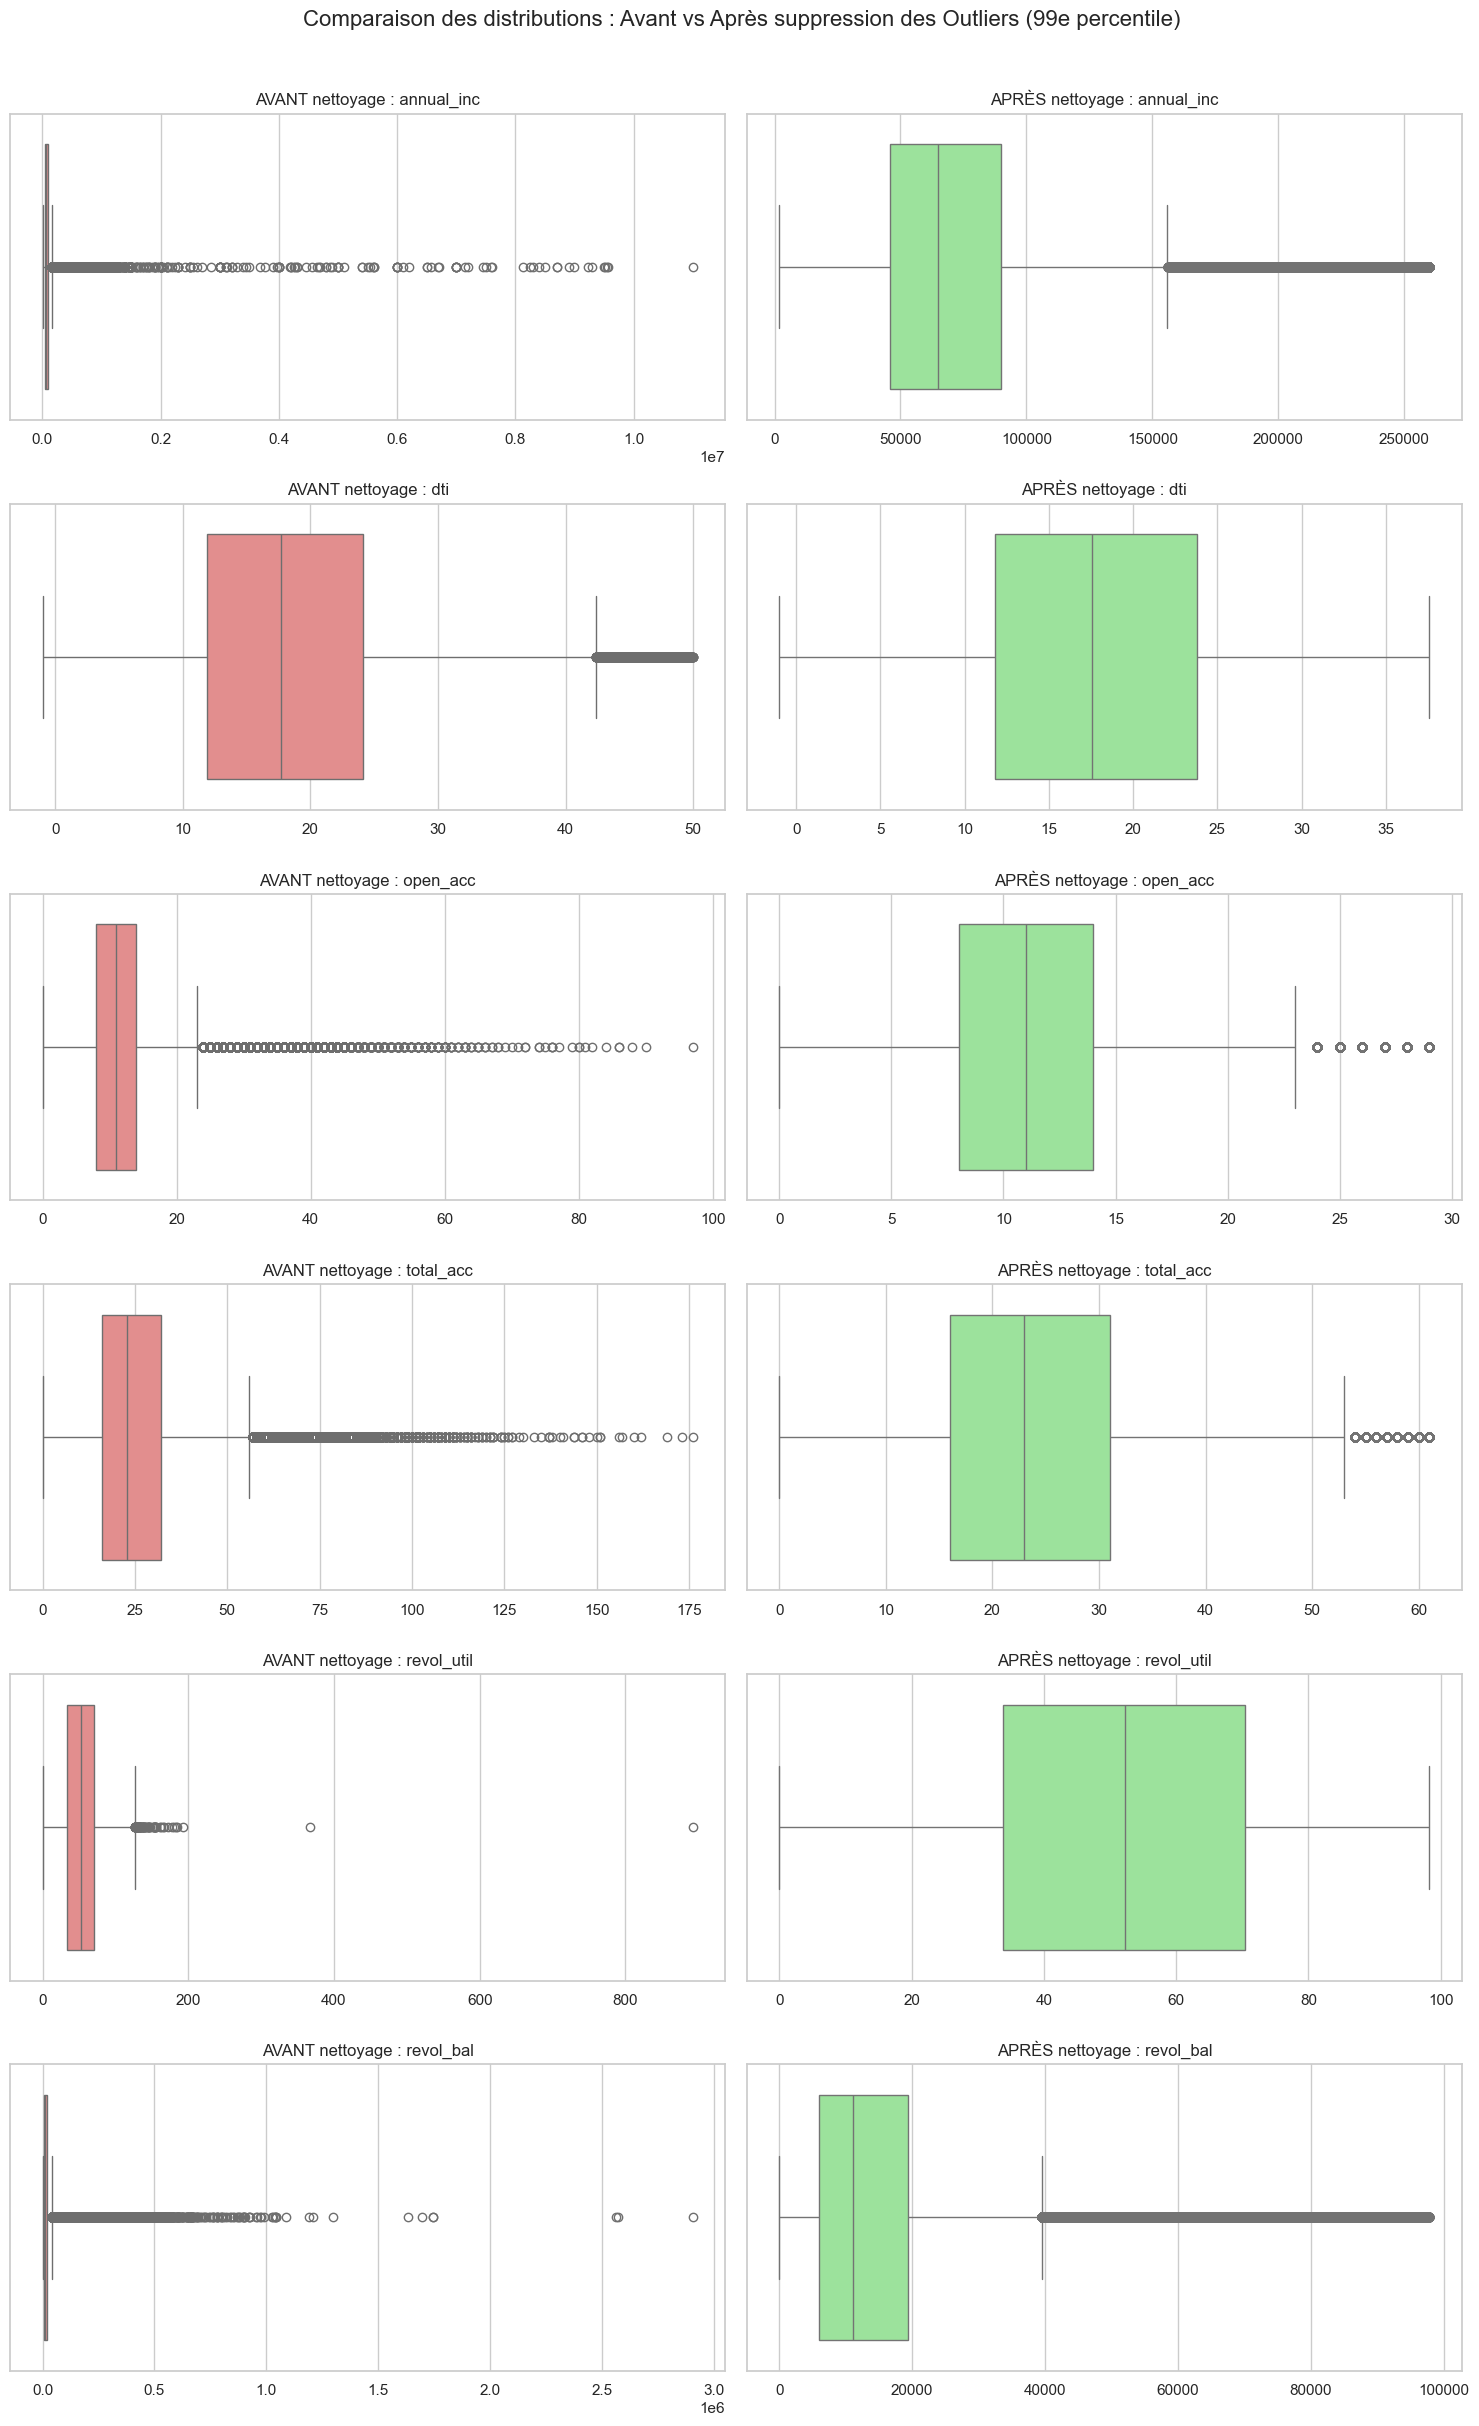

In [74]:
# Colonnes traitées
cols_to_plot = ['annual_inc', 'dti', 'open_acc', 'total_acc', 'revol_util', 'revol_bal']

# Configuration de la taille globale de la figure
fig, axes = plt.subplots(nrows=len(cols_to_plot), ncols=2, figsize=(15, 4 * len(cols_to_plot)))
fig.suptitle('Comparaison des distributions : Avant vs Après suppression des Outliers (99e percentile)', 
             fontsize=16, y=1.01)

for i, col in enumerate(cols_to_plot):
    # AVANT le nettoyage (sur fillna_df)
    sns.boxplot(x=fillna_df[col], ax=axes[i, 0], color='lightcoral')
    axes[i, 0].set_title(f'AVANT nettoyage : {col}')
    axes[i, 0].set_xlabel('')
    
    # APRÈS le nettoyage (sur RemoveOutlier_df)
    sns.boxplot(x=RemoveOutlier_df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'APRÈS nettoyage : {col}')
    axes[i, 1].set_xlabel('')

# Ajustement de l'espacement pour éviter que les titres ne se chevauchent
plt.tight_layout()
plt.show()

## F) Analyse des corrélations

Correlation analysis was performed on the variables to assess their importance and relationship to the target variable y. This provided insights into the most relevant variables for predicting good vs bad loans.

For the correlation analysis, categorical variables were label encoded to enable numeric correlation values to be calculated. While this encoding can introduce artificial numerical relationships, it provided a convenient quick view of variable importance.

For the actual model building later on, more appropriate encodings like target encoding were used for the categorical variables.

In [75]:
target_col = target_variable = "loan_condition_int"

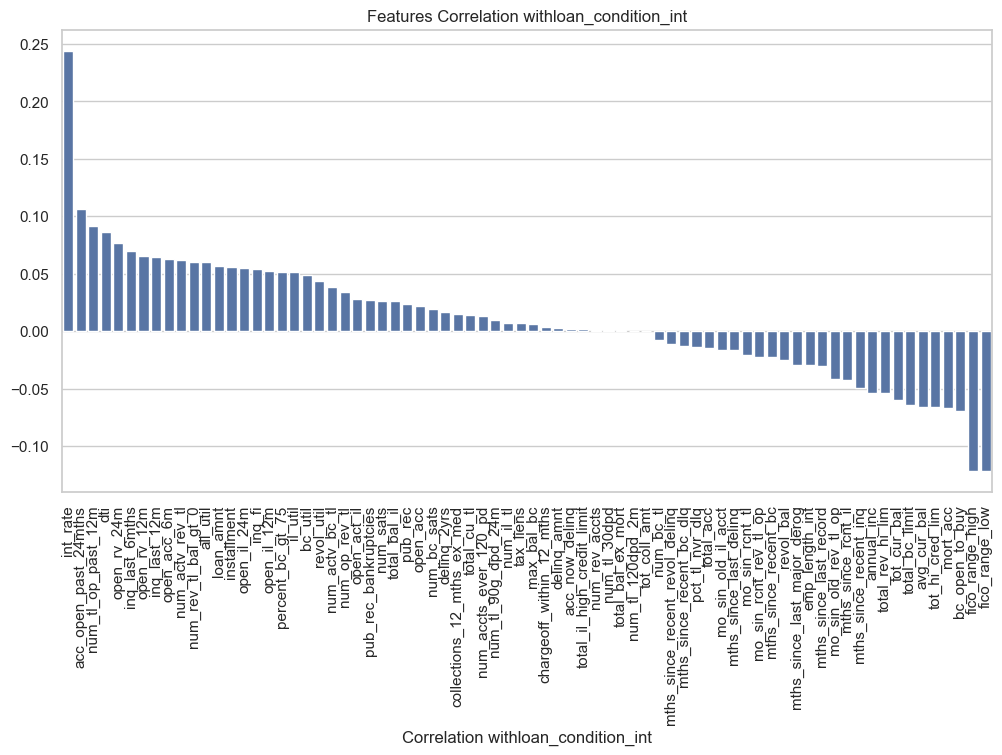

int_rate                0.244074
acc_open_past_24mths    0.106077
num_tl_op_past_12m      0.091654
dti                     0.086269
open_rv_24m             0.076523
                          ...   
tot_hi_cred_lim        -0.066386
mort_acc               -0.067143
bc_open_to_buy         -0.069116
fico_range_high        -0.121527
fico_range_low         -0.121528
Name: loan_condition_int, Length: 74, dtype: float64


In [76]:
corr_df = RemoveOutlier_df.copy() 

# correlation with y
correlation_with_loan_condition = corr_df.select_dtypes(include=['int64', 'float64']).corr()[target_variable]
sorted_correlation = correlation_with_loan_condition.drop(target_variable).sort_values(ascending=False)

# plot
plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_correlation.index, y=sorted_correlation.values, orient='v')
plt.xlabel('Correlation with{}'.format(target_variable))
plt.title('Features Correlation with{}'.format(target_variable))
plt.xticks(rotation=90)
plt.show()
print(sorted_correlation)

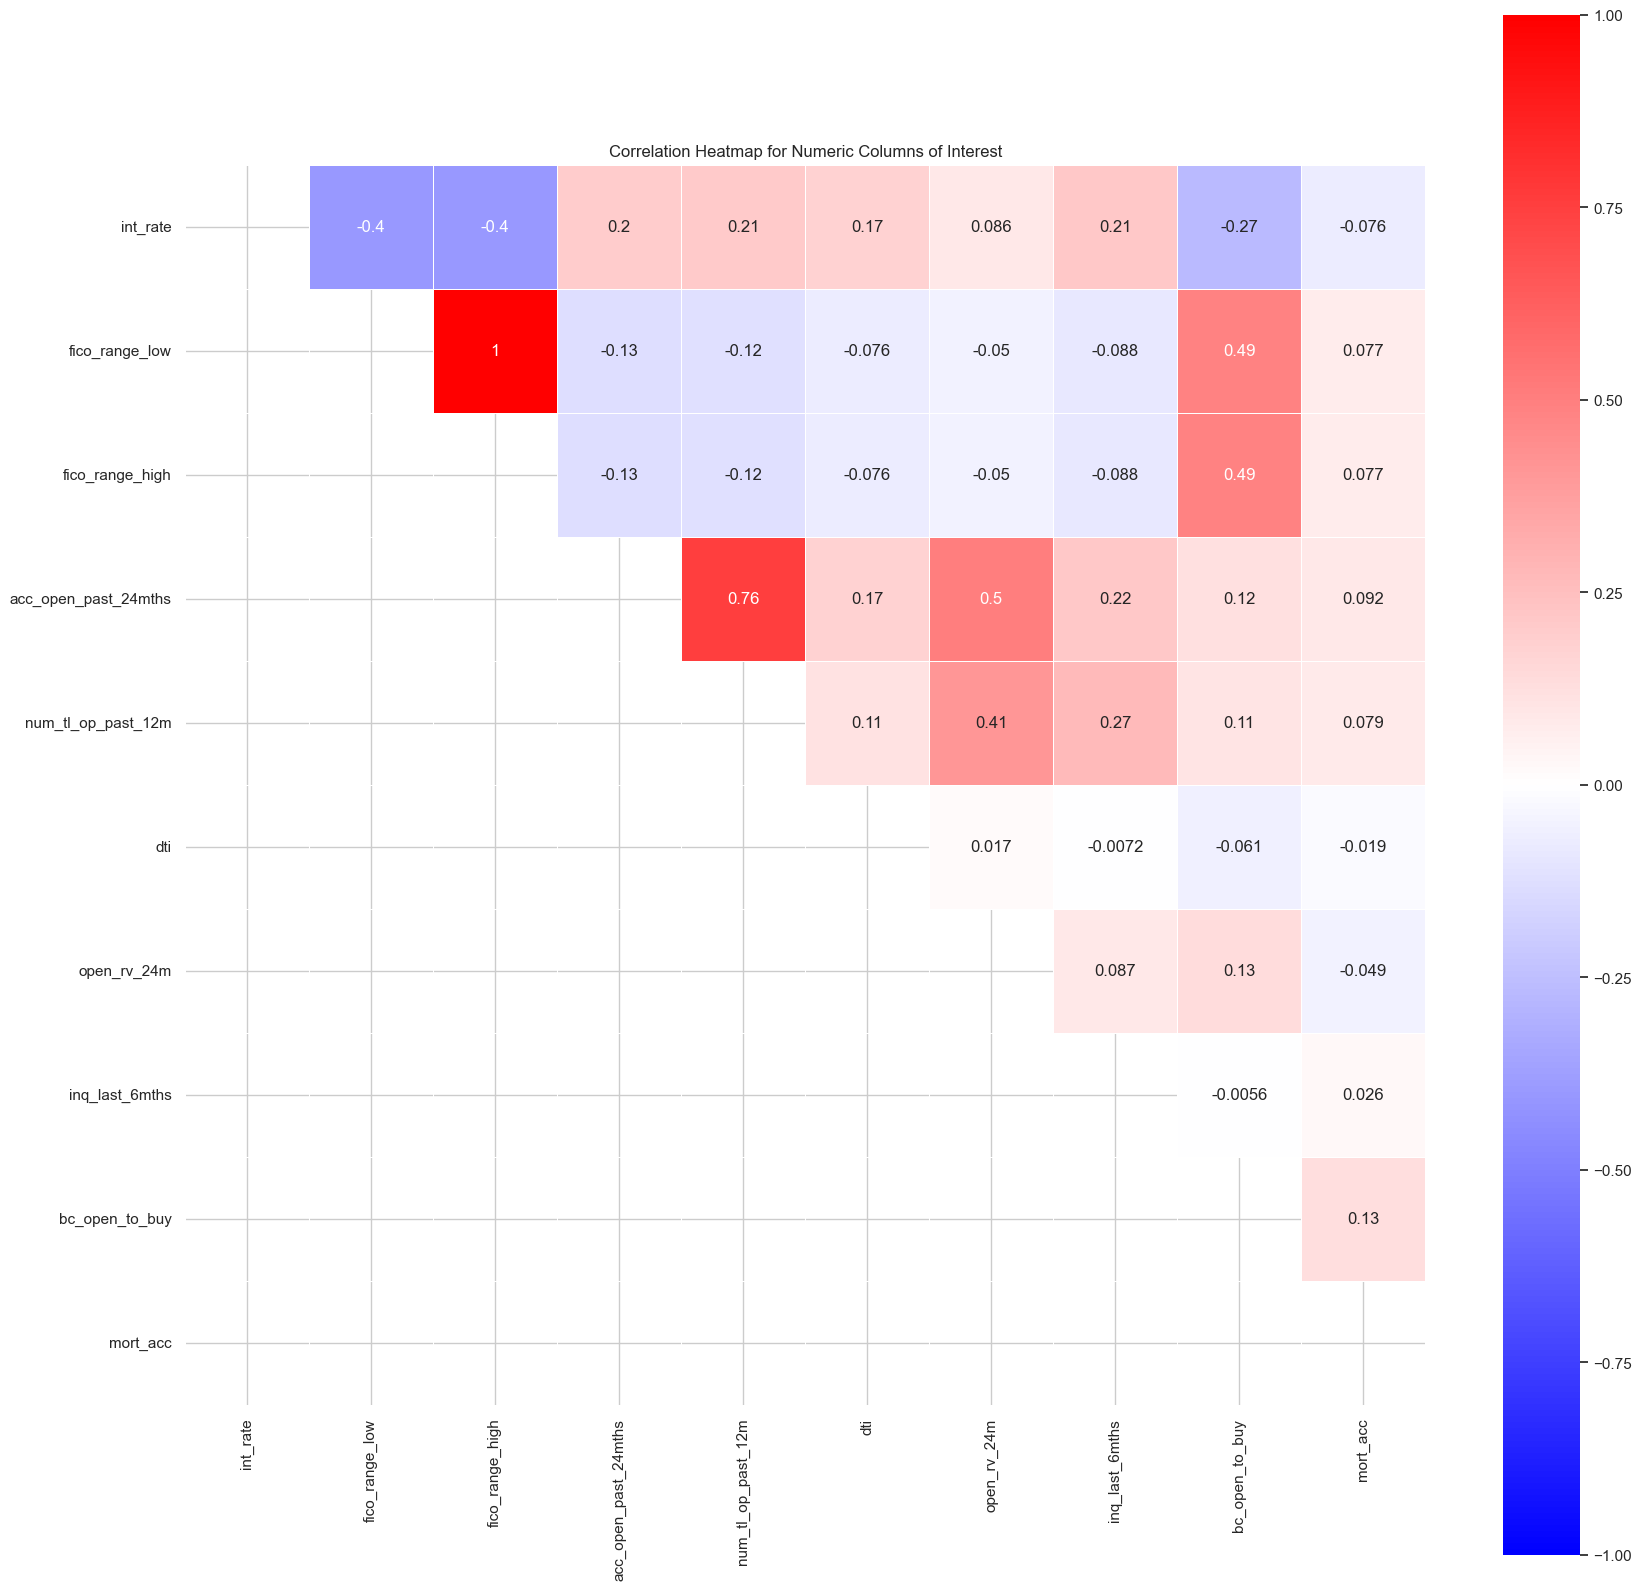

In [77]:
# Select the variables with the highest correlation with the dependent variable and explore the correlation between them
top_variables = sorted_correlation.abs().nlargest(10).index.tolist()

plt.figure(figsize=(20, 20))
correlation_matrix = RemoveOutlier_df[top_variables].corr()
mask = np.tril(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, annot=True, cmap='bwr', vmin=-1, vmax=1, square=True, linewidths=0.5, mask=mask)
plt.title('Correlation Heatmap for Numeric Columns of Interest')
plt.show()

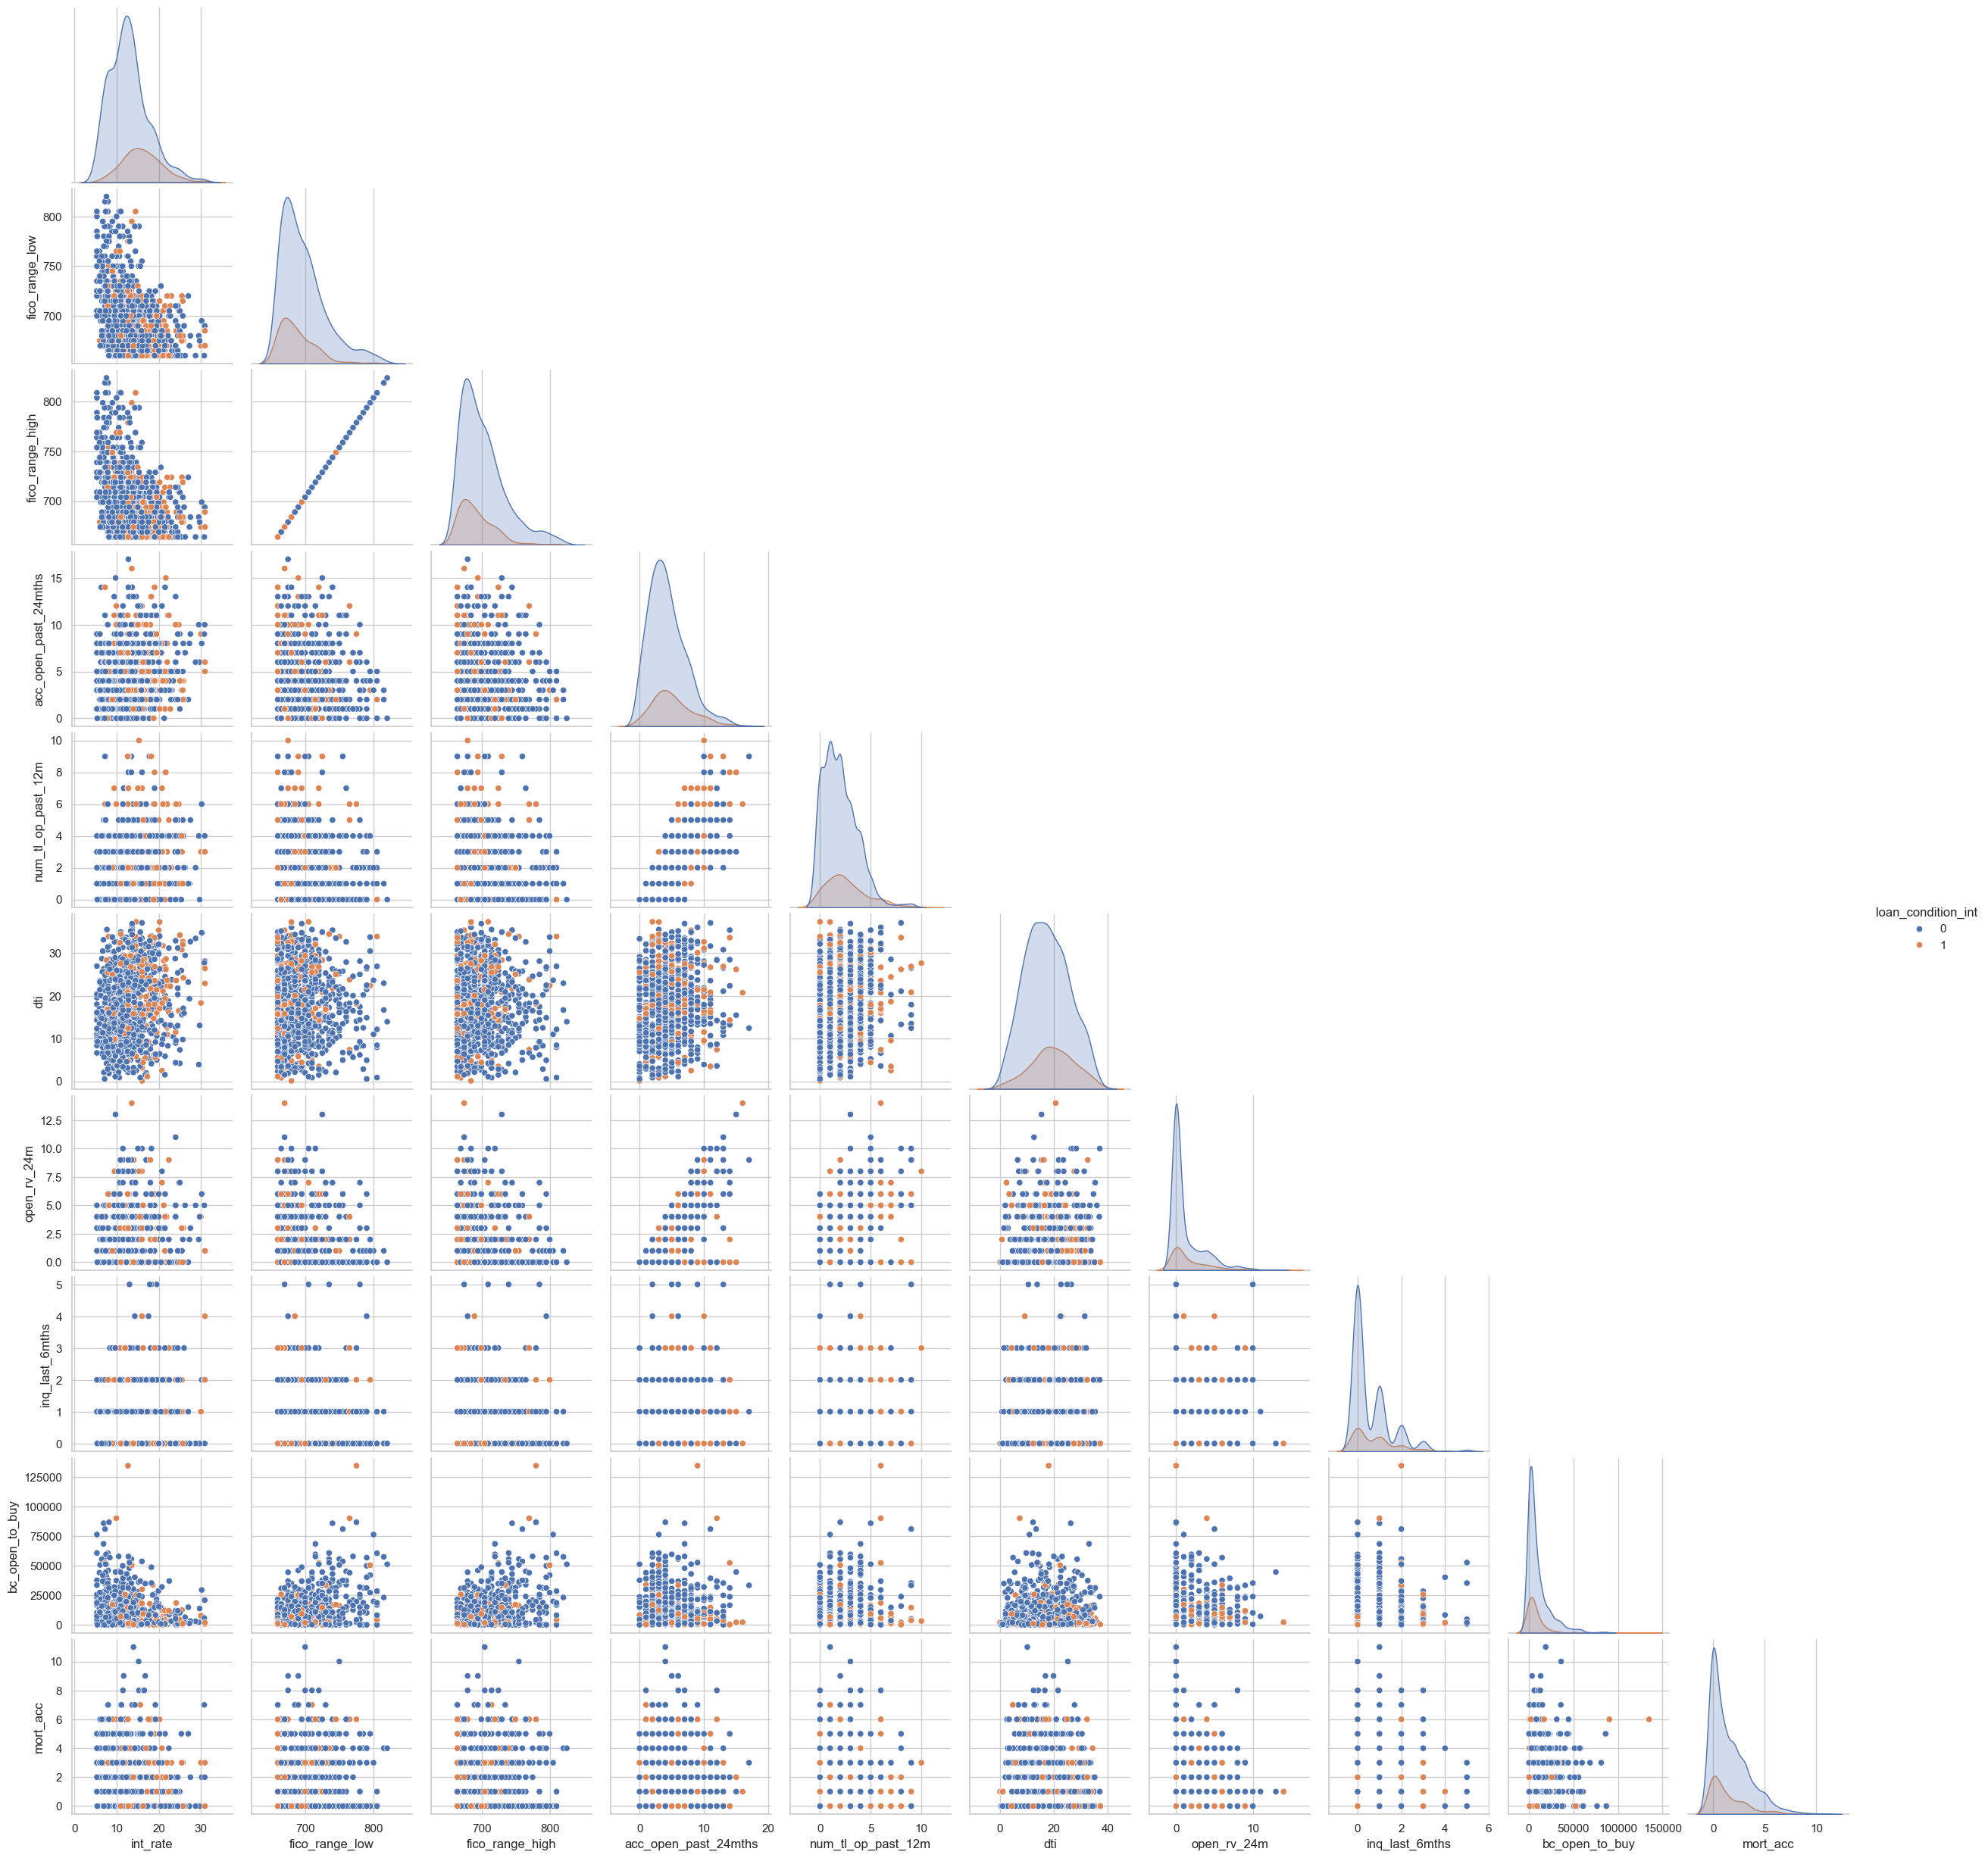

In [78]:
# # Further, explore the specific distribution of the relationship between variables under the action of the dependent variable loan_condition_int
# # This runs a bit slowly, so run with caution
sample_corr_df = corr_df[top_variables + [target_variable]].sample(n=1000, random_state=42)
sns.pairplot(sample_corr_df,hue=target_variable, diag_kind='kde',corner=True)

In [79]:
# Suppression des variables cibles textuelles qui révèlent la réponse au modèle
cols_target_leakage = ['loan_status', 'loan_condition']

RemoveOutlier_df = RemoveOutlier_df.drop(columns=cols_target_leakage, errors='ignore')

print("Les variables cibles textuelles ont été supprimées pour éviter la triche du modèle.")
print(f"Dimensions finales avant sauvegarde : {RemoveOutlier_df.shape}")

Les variables cibles textuelles ont été supprimées pour éviter la triche du modèle.
Dimensions finales avant sauvegarde : (1458649, 85)


In [80]:
# Sauvegardes en vue de la partie suivante

# Données

RemoveOutlier_df.to_parquet("DATA/cleaned_data_for_modeling.parquet")

print("Données nettoyées sauvegardées pour la phase de feature engineering.")

# Cible

with open("CONFIG/target_config.txt", "w") as f:
    f.write(target_col)

print(f"Configuration sauvegardée : la cible est '{target_col}'")

Données nettoyées sauvegardées pour la phase de feature engineering.
Configuration sauvegardée : la cible est 'loan_condition_int'


In [81]:
# 1. Liste des DF à supprimer
df_a_purger = [
    'df', 'df_bases', 'df_sample', 'EDA_df', 'data_for_tables', 
    'drop_df', 'fillna_df', 'RemoveOutlier_df', 'corr_df', 'sample_corr_df'
]

# 2. Suppression de l'environnement 
for var in df_a_purger:
    if var in locals():
        del locals()[var]

# 3. Libération de la mémoire
gc.collect()

print("🧹 Mémoire purgée avec succès ! Le notebook est prêt à être fermé.")

🧹 Mémoire purgée avec succès ! Le notebook est prêt à être fermé.


----
